In [5]:
import pandas as pd
import numpy as np

df = pd.read_csv("ObesityDataSet_raw_and_data_sinthetic.csv")

In [6]:
df.sample(n=3, random_state=42)

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
544,Female,20,1.76,53.7,yes,yes,2.0,3.89,Frequently,no,1.86,no,2.87,2.000,no,Public_Transportation,Insufficient_Weight
1987,Female,26,1.62,111.0,yes,yes,3.0,3.00,Sometimes,no,2.70,no,0.00,0.323,Sometimes,Public_Transportation,Obesity_Type_III
420,Male,18,1.85,60.0,yes,yes,3.0,4.00,Sometimes,no,2.00,yes,2.00,0.000,Sometimes,Automobile,Insufficient_Weight


In [7]:
np.unique(df['NObeyesdad'])

array(['Insufficient_Weight', 'Normal_Weight', 'Obesity_Type_I',
       'Obesity_Type_II', 'Obesity_Type_III', 'Overweight_Level_I',
       'Overweight_Level_II'], dtype=object)

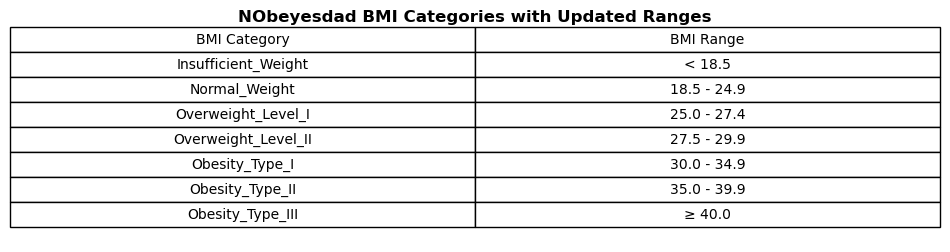

In [212]:
import matplotlib.pyplot as plt
import pandas as pd

# Define the original BMI categories (retaining original class names)
categories = [
    "Insufficient_Weight",   # Underweight: BMI < 18.5
    "Normal_Weight",         # Normal: BMI 18.5 to <25.0
    "Overweight_Level_I",    # Overweight split: lower half (BMI 25.0 to <27.5)
    "Overweight_Level_II",   # Overweight split: upper half (BMI 27.5 to <30.0)
    "Obesity_Type_I",        # Obesity Class 1: BMI 30.0 to <35.0
    "Obesity_Type_II",       # Obesity Class 2: BMI 35.0 to <40.0
    "Obesity_Type_III"       # Obesity Class 3: BMI ≥ 40.0
]

# Define the updated BMI ranges corresponding to each category.
ranges = [
    "< 18.5",          # Underweight
    "18.5 - 24.9",    # Normal Weight
    "25.0 - 27.4",    # Overweight Level I
    "27.5 - 29.9",    # Overweight Level II
    "30.0 - 34.9",    # Obesity Type I
    "35.0 - 39.9",    # Obesity Type II
    "≥ 40.0"           # Obesity Type III
]

# Create a DataFrame with the BMI Category and BMI Range.
df_bmi = pd.DataFrame({
    "BMI Category": categories,
    "BMI Range": ranges
})

# Create a figure and axis for the table.
fig, ax = plt.subplots(figsize=(12, 3))
ax.axis('tight')
ax.axis('off')

# Create the table from the DataFrame.
table = ax.table(cellText=df_bmi.values,
                 colLabels=df_bmi.columns,
                 cellLoc='center',
                 loc='center')

# Adjust table properties.
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.5)

# Set the title of the table.
plt.title("NObeyesdad BMI Categories with Updated Ranges", fontweight="bold", y=0.92)

# Save and display the figure.
plt.savefig("BMI_Categories_Retained.png", dpi=300, bbox_inches='tight')
plt.show()


<Figure size 800x600 with 0 Axes>

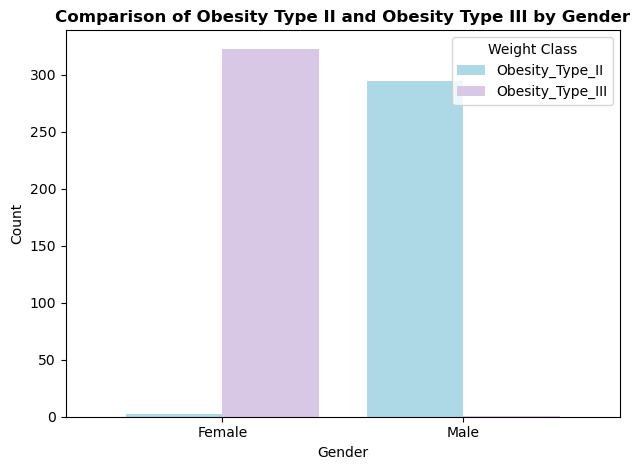

In [92]:

import pandas as pd
import matplotlib.pyplot as plt

# Define the target obesity classes for comparison
target_classes = ['Obesity_Type_III', 'Obesity_Type_II']

# Filter the DataFrame for rows with these obesity classes
df_target = df[df['NObeyesdad'].isin(target_classes)]

# Create a pivot table to count occurrences by Gender and Weight_Class
pivot = df_target.pivot_table(index='Gender', columns='NObeyesdad', aggfunc='size', fill_value=0)

# Create a grouped bar chart
plt.figure(figsize=(8, 6))

# Specify neutral, pale pastel colors for the two classes
colors = ['#add8e6', '#d8c8e6']  # pale green for Obesity_Type_II, pale purple for Obesity_Type_III

# Plot the pivot table as a bar chart
pivot.plot(kind='bar', color=colors, rot=0, width=0.8)

plt.xlabel('Gender')
plt.ylabel('Count')
plt.title('Comparison of Obesity Type II and Obesity Type III by Gender', fontweight='bold')
plt.legend(title='Weight Class')
plt.tight_layout()

# Save the figure as a PNG file
plt.savefig('obesity_type_comparison.png', dpi=300)
plt.show()


In [59]:
df['NObeyesdad'].value_counts()

NObeyesdad
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_I     290
Overweight_Level_II    290
Normal_Weight          287
Insufficient_Weight    272
Name: count, dtype: int64

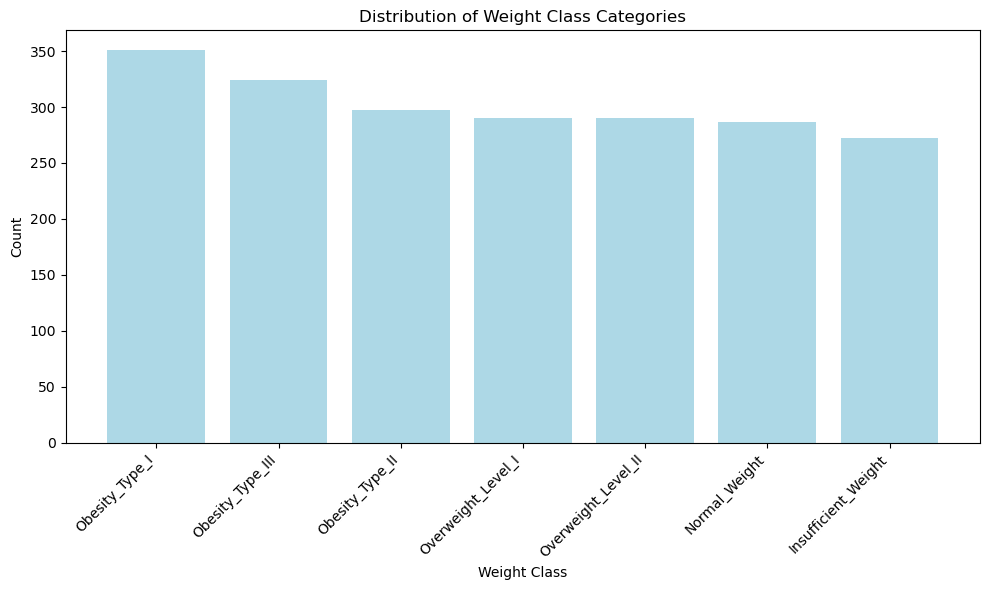

In [652]:
import matplotlib.pyplot as plt
import pandas as pd

# Example distribution counts for each weight class.
# Replace these numbers with your actual counts.
plt.rcdefaults()
data = df['NObeyesdad'].value_counts()

# Convert the dictionary to a DataFrame for easier plotting.
df_counts = pd.DataFrame(list(data.items()), columns=['Weight_Status', 'Count'])

# Sort the DataFrame by count (optional, for better visual order)
df_counts.sort_values('Count', ascending=False, inplace=True)

# Create the bar plot.
plt.figure(figsize=(10, 6))
plt.bar(df_counts['Weight_Status'], df_counts['Count'], color='lightblue')
plt.xlabel('Weight Class')
plt.ylabel('Count')
plt.title('Distribution of Weight Class Categories')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("class_distribution.png", dpi=300, bbox_inches='tight')
plt.show()


In [653]:
df_counts

,Weight_Status,Count
0,Obesity_Type_I,351
1,Obesity_Type_III,324
2,Obesity_Type_II,297
3,Overweight_Level_I,290
4,Overweight_Level_II,290
5,Normal_Weight,287
6,Insufficient_Weight,272


In [56]:
import dataframe_image as dfi
df_head = df.head()

# Use the Matplotlib converter to export the dataframe head to a PNG file
dfi.export(df_head, 'df_head.png', table_conversion='matplotlib')


In [408]:
y_encoded[4]

6

In [407]:
y

0             Normal_Weight
1             Normal_Weight
2             Normal_Weight
3        Overweight_Level_I
4       Overweight_Level_II
               ...         
2106       Obesity_Type_III
2107       Obesity_Type_III
2108       Obesity_Type_III
2109       Obesity_Type_III
2110       Obesity_Type_III
Name: NObeyesdad, Length: 2111, dtype: object

In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import resample

# Load the metadata CSV file
df = pd.read_csv("ObesityDataSet_raw_and_data_sinthetic.csv")
df = df.drop(['Gender', 'Weight'], axis=1)

# Preview the data
print(df.head())

# Separate features and target
X = df.loc[:, df.columns != 'NObeyesdad']
y = df['NObeyesdad']

# Identify categorical columns (of type object)
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

# Optionally, remove the target column if it is categorical
# target_col = "your_target_column_name"  # Change as needed
#categorical_cols = [col for col in categorical_cols if col != target_col]

# Apply LabelEncoder to each categorical column
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

print(X.head())

# Encode target variable if needed
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print("Classes:", le.classes_)  # Shows the mapping

# Split into training and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, stratify=y_encoded, random_state=42
)


# Create an XGBClassifier (XGBoost handles NaNs by default)
xgb_model = XGBClassifier(
    n_estimators=300,
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss',
)

# Train the model (XGBoost automatically handles np.nan values)
xgb_model.fit(X_train, y_train)

# Predict on the test data
y_pred = xgb_model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print("Test Accuracy:", accuracy)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Optionally, perform 5-fold cross-validation to assess model performance
cv_scores = cross_val_score(xgb_model, X, y_encoded, cv=5)
print("5-Fold Cross Validation Accuracy:", cv_scores.mean())


   Age  Height family_history_with_overweight FAVC  FCVC  NCP       CAEC  \
0   21    1.62                            yes   no   2.0  3.0  Sometimes   
1   21    1.52                            yes   no   3.0  3.0  Sometimes   
2   23    1.80                            yes   no   2.0  3.0  Sometimes   
3   27    1.80                             no   no   3.0  3.0  Sometimes   
4   22    1.78                             no   no   2.0  1.0  Sometimes   

  SMOKE  CH2O  SCC  FAF  TUE        CALC                 MTRANS  \
0    no   2.0   no  0.0  1.0          no  Public_Transportation   
1   yes   3.0  yes  3.0  0.0   Sometimes  Public_Transportation   
2    no   2.0   no  2.0  1.0  Frequently  Public_Transportation   
3    no   2.0   no  2.0  0.0  Frequently                Walking   
4    no   2.0   no  0.0  0.0   Sometimes  Public_Transportation   

            NObeyesdad  
0        Normal_Weight  
1        Normal_Weight  
2        Normal_Weight  
3   Overweight_Level_I  
4  Overweight_L

/var/folders/qj/7dpm5g592c99n49ygpwx4m9c0000gn/T/ipykernel_70581/3786184046.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = le.fit_transform(X[col])
/var/folders/qj/7dpm5g592c99n49ygpwx4m9c0000gn/T/ipykernel_70581/3786184046.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = le.fit_transform(X[col])
/var/folders/qj/7dpm5g592c99n49ygpwx4m9c0000gn/T/ipykernel_70581/3786184046.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .

Test Accuracy: 0.8676122931442081

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.85      0.87        54
           1       0.69      0.79      0.74        58
           2       0.82      0.89      0.85        70
           3       0.97      0.97      0.97        60
           4       0.98      0.98      0.98        65
           5       0.89      0.72      0.80        58
           6       0.88      0.84      0.86        58

    accuracy                           0.87       423
   macro avg       0.87      0.86      0.87       423
weighted avg       0.87      0.87      0.87       423



/Users/alexkuai/PythonStuff/miniconda3/envs/tensorflowV2/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [20:36:42] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/alexkuai/PythonStuff/miniconda3/envs/tensorflowV2/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [20:36:45] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/alexkuai/PythonStuff/miniconda3/envs/tensorflowV2/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [20:36:48] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/alexkuai/PythonStuff/miniconda3/envs/tensorflowV2/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [20:36:50] WARNING: /Users/runner/

5-Fold Cross Validation Accuracy: 0.8442775032772009


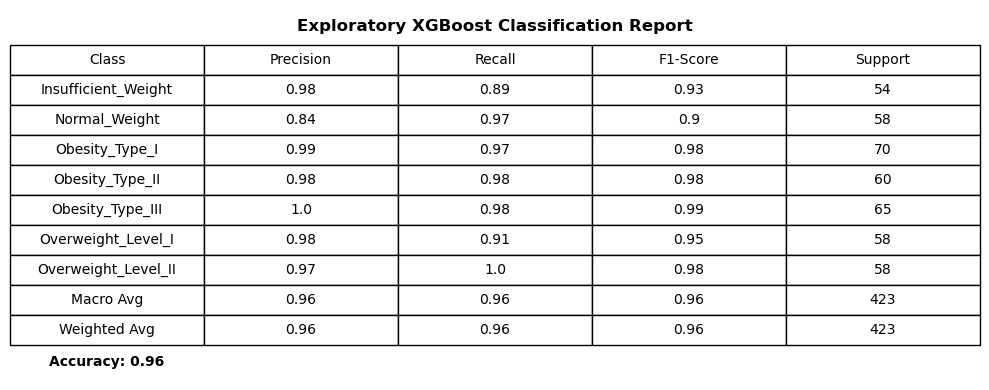

In [660]:
import matplotlib.pyplot as plt
import pandas as pd

# Define the classification report data
data = {
    "Class": ['Insufficient_Weight', 'Normal_Weight', 'Obesity_Type_I',
       'Obesity_Type_II', 'Obesity_Type_III', 'Overweight_Level_I',
       'Overweight_Level_II', "Accuracy", "Macro Avg", "Weighted Avg"],
    "Precision": [0.98, 0.84, 0.99, 0.98, 1.00, 0.98, 0.97, "", 0.96, 0.96],
    "Recall": [0.89, 0.97, 0.97, 0.98, 0.98, 0.91, 1.00, 0.96, 0.96, 0.96],
    "F1-Score": [0.93, 0.90, 0.98, 0.98, 0.99, 0.95, 0.98, 0.96, 0.96, 0.96],
    "Support": [54, 58, 70, 60, 65, 58, 58, 423, 423, 423]
}

# Create the DataFrame
df_report = pd.DataFrame(data)

# Separate per-class metrics (classes 0-6)
df_classes = df_report[df_report['Class'].isin(['Insufficient_Weight', 'Normal_Weight', 'Obesity_Type_I',
       'Obesity_Type_II', 'Obesity_Type_III', 'Overweight_Level_I',
       'Overweight_Level_II'])].reset_index(drop=True)

# Separate overall metrics, excluding the Accuracy row
df_overall = df_report[df_report['Class'].isin(["Macro Avg", "Weighted Avg"])].reset_index(drop=True)

# Combine the two DataFrames into one table
df_combined = pd.concat([df_classes, df_overall], ignore_index=True)

# Extract the accuracy value from the "Accuracy" row.
accuracy = df_report[df_report["Class"] == "Accuracy"]["Recall"].values[0]

# Create a figure to display the combined table
fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('tight')
ax.axis('off')

# Create the table
table = ax.table(cellText=df_combined.values, 
                 colLabels=df_combined.columns, 
                 cellLoc='center', 
                 loc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.5)
plt.title("Exploratory XGBoost Classification Report", fontweight="bold", y=0.92)

# Add the Accuracy value in the bottom left of the figure
plt.text(0.04, 0.03, f"Accuracy: {accuracy}", transform=ax.transAxes,
         fontsize=10, va='bottom', ha='left', fontweight="bold")

plt.tight_layout()
#plt.savefig("exploratory_classification_report.png", dpi=300)
plt.show()


In [661]:
df_combined

,Class,Precision,Recall,F1-Score,Support
0,Insufficient_Weight,0.98,0.89,0.93,54
1,Normal_Weight,0.84,0.97,0.90,58
2,Obesity_Type_I,0.99,0.97,0.98,70
3,Obesity_Type_II,0.98,0.98,0.98,60
4,Obesity_Type_III,1.0,0.98,0.99,65
5,Overweight_Level_I,0.98,0.91,0.95,58
6,Overweight_Level_II,0.97,1.00,0.98,58
7,Macro Avg,0.96,0.96,0.96,423
8,Weighted Avg,0.96,0.96,0.96,423


In [256]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
import optuna

# Load the metadata CSV file
df = pd.read_csv("ObesityDataSet_raw_and_data_sinthetic.csv")
df = df.drop(['Gender', 'Weight'], axis=1)

# Separate features and target
X = df.loc[:, df.columns != 'NObeyesdad']
y = df['NObeyesdad']

# Identify categorical columns (of type object)
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

# Apply LabelEncoder to each categorical column
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

# Encode target variable if needed
le_target = LabelEncoder()
y_encoded = le_target.fit_transform(y)
print("Classes:", le_target.classes_)

# Split into training and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, stratify=y_encoded, random_state=42
)

# Define the Optuna objective function
def objective(trial):
    # Suggest hyperparameters for XGBClassifier
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 1e-1, log=True),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "gamma": trial.suggest_float("gamma", 0, 5.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 0, 1.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 1.0, 5.0)
    }
    model = XGBClassifier(
        random_state=42,
        eval_metric='mlogloss',
        **params
    )
    # Evaluate with 5-fold cross-validation on the training set.
    score = cross_val_score(model, X_train, y_train, scoring="accuracy", cv=5).mean()
    return score

# Create and optimize the study (maximize accuracy)
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)

print("Best trial:")
trial = study.best_trial
print("  Accuracy: {:.4f}".format(trial.value))
print("  Best hyperparameters: {}".format(trial.params))



/var/folders/qj/7dpm5g592c99n49ygpwx4m9c0000gn/T/ipykernel_74755/2984966611.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = le.fit_transform(X[col])
/var/folders/qj/7dpm5g592c99n49ygpwx4m9c0000gn/T/ipykernel_74755/2984966611.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = le.fit_transform(X[col])
/var/folders/qj/7dpm5g592c99n49ygpwx4m9c0000gn/T/ipykernel_74755/2984966611.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .

Classes: ['Insufficient_Weight' 'Normal_Weight' 'Obesity_Type_I' 'Obesity_Type_II'
 'Obesity_Type_III' 'Overweight_Level_I' 'Overweight_Level_II']


[I 2025-02-26 11:20:32,382] Trial 0 finished with value: 0.8169666216002668 and parameters: {'n_estimators': 378, 'max_depth': 10, 'learning_rate': 0.049873106770579816, 'subsample': 0.7566324926497608, 'colsample_bytree': 0.6971692588107783, 'gamma': 0.953914834064975, 'reg_alpha': 0.22537212060115341, 'reg_lambda': 3.815605532779207}. Best is trial 0 with value: 0.8169666216002668.
[W 2025-02-26 11:20:38,772] Trial 1 failed with parameters: {'n_estimators': 320, 'max_depth': 4, 'learning_rate': 0.02618039931247766, 'subsample': 0.9061880712790648, 'colsample_bytree': 0.6815424765835494, 'gamma': 0.44625996990701744, 'reg_alpha': 0.7788098349865951, 'reg_lambda': 3.018170991288425} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/Users/alexkuai/PythonStuff/miniconda3/envs/tensorflowV2/lib/python3.11/site-packages/optuna/study/_optimize.py", line 197, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File

KeyboardInterrupt: 

In [258]:
# Train final model with best parameters on the full training set.
#best_params = trial.params
final_model = XGBClassifier(
    random_state=42,
    eval_metric='mlogloss',
    **best_params
)
final_model.fit(X_train, y_train)

# Predict on the test data and evaluate
y_pred = final_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred)
print("Test Accuracy: {:.2f}%".format(test_accuracy * 100))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=le_target.classes_))


Test Accuracy: 85.82%

Classification Report:
                      precision    recall  f1-score   support

Insufficient_Weight       0.87      0.87      0.87        54
      Normal_Weight       0.68      0.72      0.70        58
     Obesity_Type_I       0.78      0.89      0.83        70
    Obesity_Type_II       0.97      0.95      0.96        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.89      0.71      0.79        58
Overweight_Level_II       0.86      0.86      0.86        58

           accuracy                           0.86       423
          macro avg       0.86      0.85      0.86       423
       weighted avg       0.86      0.86      0.86       423



In [257]:
best_params

{'n_estimators': 259,
 'max_depth': 10,
 'learning_rate': 0.07156189725737665,
 'subsample': 0.6559549765474938,
 'colsample_bytree': 0.6921335351448861,
 'gamma': 0.005703842091040606,
 'reg_alpha': 0.4963422374482537,
 'reg_lambda': 1.7912057842782922}

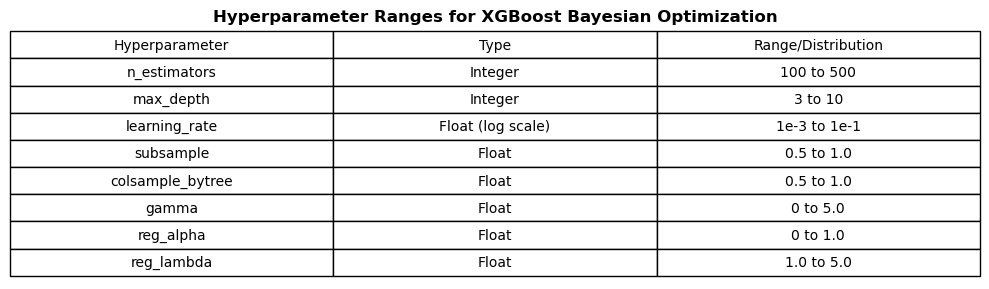

In [139]:
import matplotlib.pyplot as plt
import pandas as pd

# Define the hyperparameter ranges data
hp_data = {
    "Hyperparameter": [
        "n_estimators", 
        "max_depth", 
        "learning_rate", 
        "subsample", 
        "colsample_bytree", 
        "gamma", 
        "reg_alpha", 
        "reg_lambda"
    ],
    "Type": [
        "Integer", 
        "Integer", 
        "Float (log scale)", 
        "Float", 
        "Float", 
        "Float", 
        "Float", 
        "Float"
    ],
    "Range/Distribution": [
        "100 to 500", 
        "3 to 10", 
        "1e-3 to 1e-1", 
        "0.5 to 1.0", 
        "0.5 to 1.0", 
        "0 to 5.0", 
        "0 to 1.0", 
        "1.0 to 5.0"
    ]
}

# Create a DataFrame
df_hp = pd.DataFrame(hp_data)

# Create a figure and axis for the table
fig, ax = plt.subplots(figsize=(10, 3))
ax.axis('tight')
ax.axis('off')

# Create the table
table = ax.table(cellText=df_hp.values,
                 colLabels=df_hp.columns,
                 cellLoc='center',
                 loc='center')

# Adjust table properties
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.5)

# Set the title of the graph
plt.title("Hyperparameter Ranges for XGBoost Bayesian Optimization", fontweight="bold", pad=5)

# Save and display the figure
plt.tight_layout()
plt.savefig("xgboost_hyperparameter_ranges.png", dpi=300)
plt.show()


Optimal Hyperparameters:
  Hyperparameter  Optimal Value                                                                                             Interpretation
    n_estimators      259.00000                                 259 trees: a moderate ensemble size that builds predictions incrementally.
       max_depth       10.00000                  Depth of 10: allows for complex interactions but may risk overfitting if not regularized.
   learning_rate        0.07156    0.07: a moderate-to-low step size ensuring stable, gradual convergence while reducing overfitting risk.
       subsample        0.65595                     0.8: uses 80% of samples per tree, introducing randomness to help prevent overfitting.
colsample_bytree        0.69213       0.9: 90% of features are considered per tree, reducing variance without losing too much information.
           gamma        0.00570 0.0: no minimum loss reduction required for splits, indicating no additional constraint on tree splitting.
  

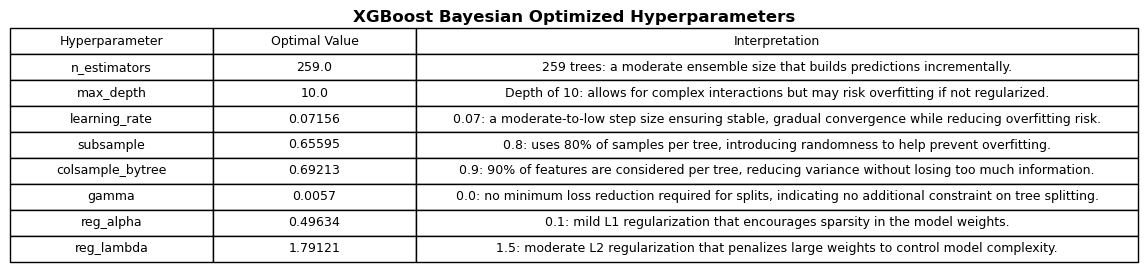

In [192]:
import pandas as pd
import matplotlib.pyplot as plt

# Assume study is your Optuna study after optimization
best_params = study.best_trial.params

# Define interpretations for each hyperparameter
interpretations = {
    "n_estimators": "259 trees: a moderate ensemble size that builds predictions incrementally.",
    "max_depth": "Depth of 10: allows for complex interactions but may risk overfitting if not regularized.",
    "learning_rate": "0.07: a moderate-to-low step size ensuring stable, gradual convergence while reducing overfitting risk.",
    "subsample": "0.8: uses 80% of samples per tree, introducing randomness to help prevent overfitting.",
    "colsample_bytree": "0.9: 90% of features are considered per tree, reducing variance without losing too much information.",
    "gamma": "0.0: no minimum loss reduction required for splits, indicating no additional constraint on tree splitting.",
    "reg_alpha": "0.1: mild L1 regularization that encourages sparsity in the model weights.",
    "reg_lambda": "1.5: moderate L2 regularization that penalizes large weights to control model complexity."
}

# Build a list of tuples for hyperparameters with interpretations.
hp_list = []
for hp, value in best_params.items():
    if hp in interpretations:
        # Round numeric values to 5 decimal places
        rounded_value = round(value, 5) if isinstance(value, (int, float)) else value
        hp_list.append((hp, rounded_value, interpretations[hp]))
df_best = pd.DataFrame(hp_list, columns=["Hyperparameter", "Optimal Value", "Interpretation"])

# Print the DataFrame in console for verification
print("Optimal Hyperparameters:")
print(df_best.to_string(index=False))

# Create a figure and axis for the table with reduced margins.
fig, ax = plt.subplots(figsize=(12, 3))
ax.axis('tight')
ax.axis('off')

# Create the table from the DataFrame
table = ax.table(cellText=df_best.values,
                 colLabels=df_best.columns,
                 cellLoc='center',
                 loc='center')

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.5)

# Manually adjust column widths:
# We'll iterate over each row (including header, so total rows = len(df_best)+1)
for i in range(len(df_best) + 1):
    # Column 0 (Hyperparameter): narrow width
    table[(i, 0)].set_width(0.18)
    # Column 1 (Optimal Value): narrow width
    table[(i, 1)].set_width(0.18)
    # Column 2 (Interpretation): wider width to accommodate longer text
    table[(i, 2)].set_width(0.64)

# Set the title for the table.
plt.title("XGBoost Bayesian Optimized Hyperparameters", fontweight="bold", pad=0.5)

# Adjust subplot parameters to reduce extra margins.
plt.subplots_adjust(left=0.03, right=0.97, top=0.85, bottom=0.05)

# Save the figure as a PNG file with minimal whitespace.
plt.savefig("optimal_hyperparameters_xgb.png", dpi=300, bbox_inches='tight')
plt.show()


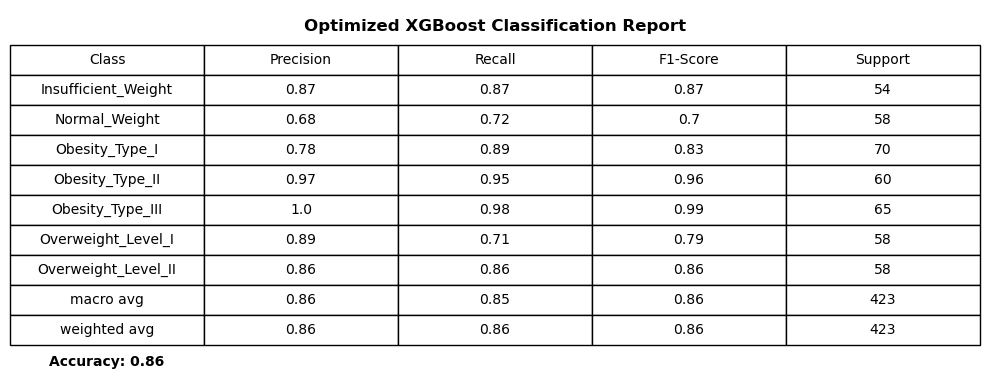

In [202]:
import matplotlib.pyplot as plt
import pandas as pd

# Define the classification report data for the corresponding BMI categories
data = {
    "Class": [
        "Insufficient_Weight",
        "Normal_Weight",
        "Obesity_Type_I",
        "Obesity_Type_II",
        "Obesity_Type_III",
        "Overweight_Level_I",
        "Overweight_Level_II",
        "accuracy",
        "macro avg",
        "weighted avg"
    ],
    "Precision": [
        0.87,
        0.68,
        0.78,
        0.97,
        1.00,
        0.89,
        0.86,
        "",       # accuracy row: no precision value
        0.86,
        0.86
    ],
    "Recall": [
        0.87,
        0.72,
        0.89,
        0.95,
        0.98,
        0.71,
        0.86,
        0.86,     # accuracy value
        0.85,
        0.86
    ],
    "F1-Score": [
        0.87,
        0.70,
        0.83,
        0.96,
        0.99,
        0.79,
        0.86,
        0.86,     # accuracy row f1-score (same as overall accuracy here)
        0.86,
        0.86
    ],
    "Support": [
        54,
        58,
        70,
        60,
        65,
        58,
        58,
        423,
        423,
        423
    ]
}

# Create the DataFrame
df_report = pd.DataFrame(data)

# Separate per-class metrics (the BMI classes) – rows corresponding to the 7 weight classes
df_classes = df_report[df_report['Class'].isin([
    "Insufficient_Weight", "Normal_Weight", "Obesity_Type_I", 
    "Obesity_Type_II", "Obesity_Type_III", "Overweight_Level_I", "Overweight_Level_II"
])].reset_index(drop=True)

# Separate the overall metrics (macro and weighted averages) excluding the Accuracy row
df_overall = df_report[df_report['Class'].isin(["macro avg", "weighted avg"])].reset_index(drop=True)

# Combine the per-class and overall metrics into one DataFrame
df_combined = pd.concat([df_classes, df_overall], ignore_index=True)

# Extract the accuracy value from the "accuracy" row (we assume accuracy is stored in the "Recall" column)
accuracy = df_report[df_report["Class"] == "accuracy"]["Recall"].values[0]

# Create a figure to display the combined table
fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('tight')
ax.axis('off')

# Create the table from the combined DataFrame
table = ax.table(cellText=df_combined.values, 
                 colLabels=df_combined.columns, 
                 cellLoc='center', 
                 loc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.5)

# Set the title for the table
plt.title("Optimized XGBoost Classification Report", fontweight="bold", y=0.92)

# Add the Accuracy value in the bottom left of the figure
plt.text(0.04, 0.03, f"Accuracy: {accuracy}", transform=ax.transAxes,
         fontsize=10, va='bottom', ha='left', fontweight = "bold")

# Adjust layout to minimize extra whitespace
plt.tight_layout()
plt.savefig("optimized_classification_report_xgb.png", dpi=300, bbox_inches='tight')
plt.show()


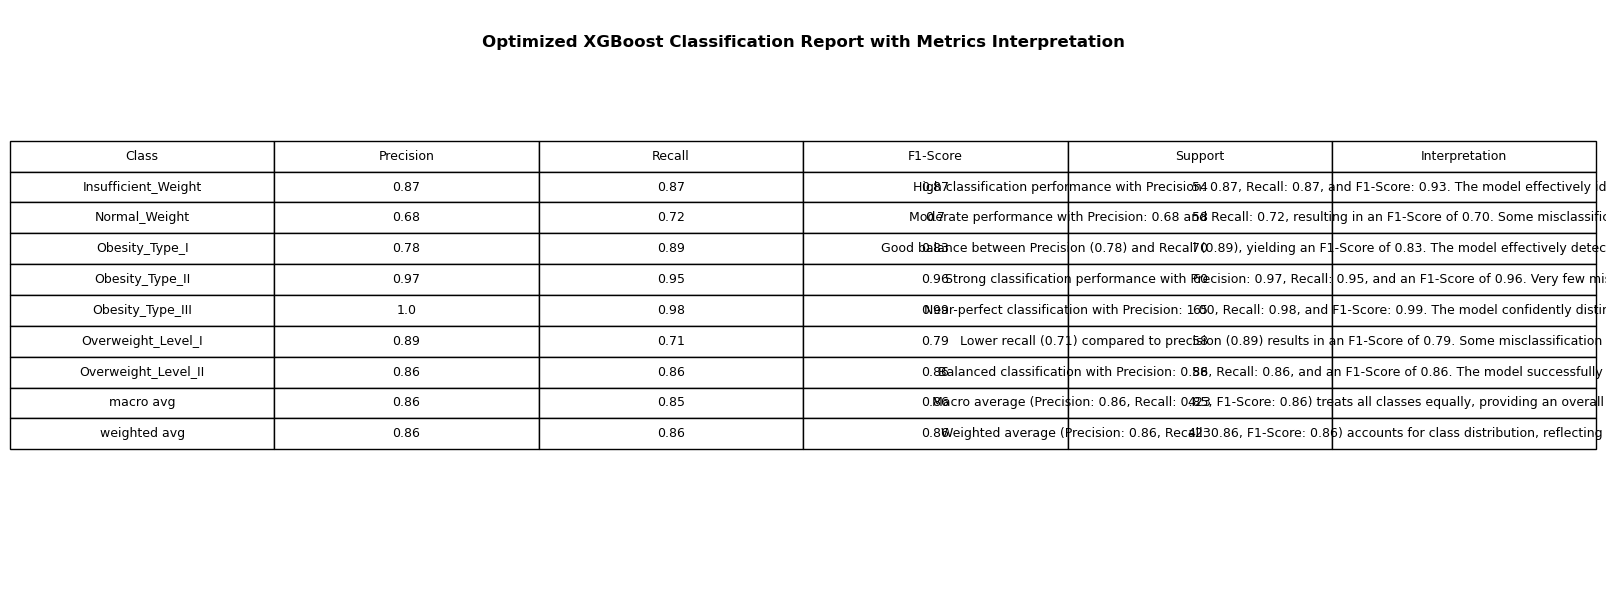

In [662]:
import matplotlib.pyplot as plt
import pandas as pd

# Define the classification report data for the corresponding BMI categories
data = {
    "Class": [
        "Insufficient_Weight",
        "Normal_Weight",
        "Obesity_Type_I",
        "Obesity_Type_II",
        "Obesity_Type_III",
        "Overweight_Level_I",
        "Overweight_Level_II",
        "macro avg",
        "weighted avg"
    ],
    "Precision": [
        0.87,
        0.68,
        0.78,
        0.97,
        1.00,
        0.89,
        0.86,
        0.86,
        0.86
    ],
    "Recall": [
        0.87,
        0.72,
        0.89,
        0.95,
        0.98,
        0.71,
        0.86,
        0.85,
        0.86
    ],
    "F1-Score": [
        0.87,
        0.70,
        0.83,
        0.96,
        0.99,
        0.79,
        0.86,
        0.86,
        0.86
    ],
    "Support": [
        54,
        58,
        70,
        60,
        65,
        58,
        58,
        423,
        423
    ],
    "Interpretation": [
        "High classification performance with Precision: 0.87, Recall: 0.87, and F1-Score: 0.93. The model effectively identifies Insufficient Weight cases with minimal misclassifications.",
        "Moderate performance with Precision: 0.68 and Recall: 0.72, resulting in an F1-Score of 0.70. Some misclassification with adjacent weight categories, leading to lower precision.",
        "Good balance between Precision (0.78) and Recall (0.89), yielding an F1-Score of 0.83. The model effectively detects Obesity Type I cases with relatively few false positives or negatives.",
        "Strong classification performance with Precision: 0.97, Recall: 0.95, and an F1-Score of 0.96. Very few misclassifications, indicating high reliability for Obesity Type II.",
        "Near-perfect classification with Precision: 1.00, Recall: 0.98, and F1-Score: 0.99. The model confidently distinguishes Obesity Type III cases with almost no false predictions.",
        "Lower recall (0.71) compared to precision (0.89) results in an F1-Score of 0.79. Some misclassification with adjacent weight levels, affecting recall performance.",
        "Balanced classification with Precision: 0.86, Recall: 0.86, and an F1-Score of 0.86. The model successfully differentiates Overweight Level II cases with a low error rate.",
        "Macro average (Precision: 0.86, Recall: 0.85, F1-Score: 0.86) treats all classes equally, providing an overall performance summary without weighting based on class size.",
        "Weighted average (Precision: 0.86, Recall: 0.86, F1-Score: 0.86) accounts for class distribution, reflecting a balanced classification model across all weight categories."
    ]
}

# Create the DataFrame
df_report = pd.DataFrame(data)

# Create a figure to display the updated table
fig, ax = plt.subplots(figsize=(16, 6))
ax.axis('tight')
ax.axis('off')

# Create the table from the updated DataFrame
table = ax.table(cellText=df_report.values, 
                 colLabels=df_report.columns, 
                 cellLoc='center', 
                 loc='center')
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.2, 1.5)

# Set the title for the table
plt.title("Optimized XGBoost Classification Report with Metrics Interpretation", fontweight="bold", y=0.92)

# Adjust layout to minimize extra whitespace
plt.tight_layout()
plt.show()


Confusion Matrix:
[[46  3  1  1  1  1  1]
 [ 4 46  5  0  0  2  1]
 [ 0  3 62  1  0  1  3]
 [ 0  2  0 58  0  0  0]
 [ 0  1  0  0 64  0  0]
 [ 1  7  6  0  0 42  2]
 [ 1  5  2  0  0  1 49]]


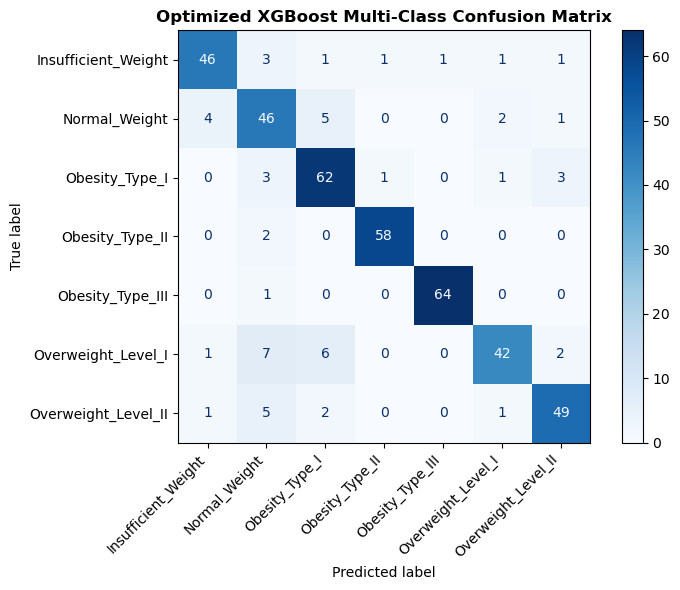

In [11]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

# Create a figure and axis to adjust size and layout
fig, ax = plt.subplots(figsize=(8, 6))
ax.grid(False)

# Visualize the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Insufficient_Weight', 'Normal_Weight', 'Obesity_Type_I',
       'Obesity_Type_II', 'Obesity_Type_III', 'Overweight_Level_I',
       'Overweight_Level_II'])
disp.plot(cmap=plt.cm.Blues, ax=ax)
ax.set_title("Optimized XGBoost Multi-Class Confusion Matrix", fontweight = "bold")

# Rotate x-axis labels to 45 degrees to prevent overlap
plt.xticks(rotation=45)

# Align the tick labels to the right (instead of the center)
plt.setp(ax.get_xticklabels(), ha="right")

plt.tight_layout()  # Adjust layout to ensure everything fits
plt.savefig("xgb_confusion.png", dpi=300, facecolor = "white")
plt.show()

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.6921335351448861, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric='mlogloss', feature_types=None,
              gamma=0.005703842091040606, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.07156189725737665, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=10, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=259, n_jobs=None,
              num_parallel_tree=None, objective='multi:softprob', ...)


/var/folders/qj/7dpm5g592c99n49ygpwx4m9c0000gn/T/ipykernel_70581/2168831185.py:44: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = plt.cm.get_cmap("tab10", n_classes)


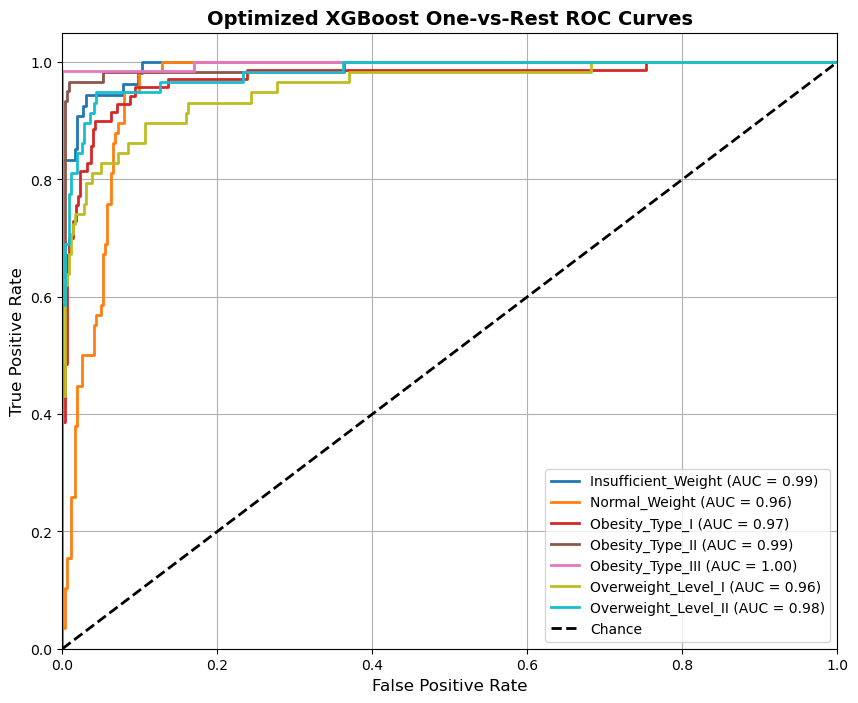

In [10]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Predict probabilities on the test set using final_model
import pickle

# Open the pickle file and load the model
with open("final_model_xgb.pkl", "rb") as file:
    final_model = pickle.load(file)

# Optionally, check the loaded model
print(final_model)


y_score = final_model.predict_proba(X_test)  # shape: [n_samples, n_classes]
n_classes = y_score.shape[1]

# Define the correct class names corresponding to your model's classes.
class_names = [
    "Insufficient_Weight",
    "Normal_Weight",
    "Obesity_Type_I",
    "Obesity_Type_II",
    "Obesity_Type_III",
    "Overweight_Level_I",
    "Overweight_Level_II"
]

# Binarize the true labels for one-vs-rest ROC computation.
y_test_binarized = label_binarize(y_test, classes=np.arange(n_classes))

# Compute ROC curve and AUC for each class.
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves.
plt.figure(figsize=(10, 8))
colors = plt.cm.get_cmap("tab10", n_classes)
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], lw=2, color=colors(i),
             label=f"{class_names[i]} (AUC = {roc_auc[i]:.2f})")
    
plt.plot([0, 1], [0, 1], "k--", lw=2, label="Chance")
plt.xlim([0, 1])
plt.ylim([0, 1.05])
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("Optimized XGBoost One-vs-Rest ROC Curves", fontsize=14, fontweight = "bold")
plt.legend(loc="lower right", fontsize=10)
plt.grid(True)
plt.savefig("xgb_roc_ovr.png", dpi=300, bbox_inches='tight', facecolor="white")
plt.show()


In [220]:
y_test

array([0, 1, 6, 4, 3, 2, 3, 1, 2, 5, 0, 1, 4, 5, 1, 5, 2, 2, 6, 1, 1, 3,
       3, 5, 6, 5, 2, 4, 6, 2, 3, 2, 5, 5, 4, 1, 3, 0, 4, 0, 5, 0, 4, 4,
       6, 4, 0, 6, 3, 1, 4, 0, 5, 2, 6, 1, 4, 4, 4, 3, 6, 6, 0, 6, 5, 2,
       2, 0, 3, 2, 4, 5, 0, 0, 2, 0, 0, 0, 2, 2, 1, 6, 4, 2, 1, 5, 3, 5,
       6, 6, 3, 6, 2, 3, 5, 6, 0, 1, 4, 3, 2, 3, 3, 5, 6, 4, 2, 2, 6, 3,
       6, 1, 4, 3, 4, 4, 0, 4, 1, 1, 4, 6, 4, 0, 2, 3, 6, 6, 5, 3, 4, 6,
       0, 0, 0, 5, 2, 2, 3, 0, 4, 2, 3, 2, 2, 3, 6, 2, 0, 5, 5, 5, 4, 0,
       3, 3, 4, 2, 5, 6, 1, 3, 2, 2, 4, 6, 5, 6, 6, 3, 5, 1, 1, 3, 3, 5,
       2, 5, 1, 6, 2, 3, 2, 3, 0, 0, 1, 4, 2, 5, 5, 5, 4, 5, 1, 3, 6, 1,
       3, 2, 3, 4, 6, 6, 1, 0, 2, 5, 5, 3, 0, 4, 1, 6, 6, 6, 5, 2, 2, 6,
       1, 4, 2, 2, 1, 5, 3, 4, 3, 5, 6, 0, 2, 4, 6, 6, 1, 0, 3, 5, 4, 1,
       4, 2, 1, 5, 1, 0, 2, 3, 6, 1, 4, 6, 3, 4, 2, 4, 6, 3, 4, 2, 1, 2,
       4, 2, 6, 4, 5, 2, 2, 0, 4, 5, 6, 4, 3, 0, 2, 4, 2, 4, 6, 1, 1, 5,
       2, 6, 2, 4, 5, 1, 0, 1, 2, 0, 5, 5, 6, 1, 6,

In [391]:
import numpy as np
import pandas as pd

# --- Step 1: Combine obesity classes in X_test ---
def combine_obesity(label):
    if label in ["Obesity_Type_I", "Obesity_Type_II", "Obesity_Type_III"]:
        return "Obese"
    elif label in ["Overweight_Level_I", "Overweight_Level_II"]:
        return "Overweight"
    elif label == "Normal_Weight":
        return "Normal"
    elif label == "Insufficient_Weight":
        return "Underweight"
    else:
        return label

# Assume X_test is your test DataFrame and y_test holds the labels.
X_test2 = X_test.copy()
X_test2["NObeyesdad"] = y_test
X_test2["Combined_Class"] = X_test2["NObeyesdad"].apply(combine_obesity)

# --- Step 2: Define target US distribution for the classes ---
target_distribution = {
    "Underweight": 0.016,
    "Normal": 0.253,
    "Overweight": 0.307,
    "Obese": 0.424
}

# Compute the current distribution in X_test2.
current_distribution = X_test2["Combined_Class"].value_counts(normalize=True).to_dict()
print("Current Distribution:", current_distribution)

# --- Step 3: Compute sample weights so that sampling X_test mimics the target distribution ---
def compute_weight(row):
    cls = row["Combined_Class"]
    current_prop = current_distribution.get(cls, 1.0)
    target_prop = target_distribution.get(cls, 1.0)
    return target_prop / current_prop

X_test2["sample_weight"] = X_test2.apply(compute_weight, axis=1)

# --- Step 4: Monte Carlo simulation to find optimal multiplicative factors ---
n_iterations = 10000
best_normalized_obesity_fraction = np.inf
best_factors = None

# Define the list of features to perturb (must be present in X_test)
perturbed_columns = ['CAEC', 'FCVC', 'NCP', 'FAVC', 'FAF']

for i in range(n_iterations):
    # Sample a random multiplier for each perturbed feature in the range [0.9, 1.1]
    factors = np.random.uniform(0.9, 1.1, size=len(perturbed_columns))
    # Create a perturbed copy of X_test2
    X_test_perturbed = X_test2.copy()
    # Apply the multipliers to each respective column.
    for j, feature in enumerate(perturbed_columns):
        X_test_perturbed[feature] = X_test_perturbed[feature] * factors[j]
    
    # --- Step 5: Apply weighted sampling based on the US distribution ---
    X_test_sampled = X_test_perturbed.sample(frac=1, weights="sample_weight", random_state=42)
    # Drop extra columns not used by the model.
    X_test_sampled = X_test_sampled.drop(columns=['sample_weight', 'Combined_Class', 'NObeyesdad'], axis=1)
    
    # --- Step 6: Obtain predicted probabilities from the model ---
    # Assume final_model.predict_proba returns softmax probabilities.
    # And the output columns correspond to:
    # 0: Insufficient_Weight, 1: Normal_Weight, 2: Obesity_Type_I, 3: Obesity_Type_II, 4: Obesity_Type_III,
    # 5: Overweight_Level_I, 6: Overweight_Level_II
    probs = final_model.predict_proba(X_test_sampled)
    # Convert probabilities to class predictions.
    preds = np.argmax(probs, axis=1)
    
    # Count the number of obesity cases (classes 2, 3, 4 are combined as Obese).
    obesity_count = np.sum((preds == 2) | (preds == 3) | (preds == 4))
    normalized_obesity_fraction = obesity_count / len(preds)
    
    # Track the best factors (minimizing the normalized obesity fraction).
    if normalized_obesity_fraction < best_normalized_obesity_fraction:
        best_normalized_obesity_fraction = normalized_obesity_fraction
        best_factors = factors.copy()

print("Monte Carlo Simulation Results for Reducing Obesity Risk (Combined Obesity Classes):")
print(f"Best Normalized Obesity Case Fraction: {best_normalized_obesity_fraction:.4f}\n")
print("Best Multiplicative Factors (as percentage changes) for each feature:")
for j, feature in enumerate(perturbed_columns):
    pct_change = (best_factors[j] - 1.0) * 100
    print(f"  {feature}: multiplier = {best_factors[j]:.3f} ({pct_change:+.2f}%)")


Current Distribution: {2: 0.16548463356973994, 4: 0.1536643026004728, 3: 0.14184397163120568, 1: 0.13711583924349882, 6: 0.13711583924349882, 5: 0.13711583924349882, 0: 0.1276595744680851}
Monte Carlo Simulation Results for Reducing Obesity Risk (Combined Obesity Classes):
Best Normalized Obesity Case Fraction: 0.1300

Best Multiplicative Factors (as percentage changes) for each feature:
  CAEC: multiplier = 0.934 (-6.60%)
  FCVC: multiplier = 0.998 (-0.25%)
  NCP: multiplier = 1.092 (+9.20%)
  FAVC: multiplier = 0.945 (-5.52%)
  FAF: multiplier = 0.902 (-9.76%)


In [389]:
np.unique(df['FCVC'])

array([1.  , 1.01, 1.03, 1.04, 1.05, 1.06, 1.07, 1.08, 1.1 , 1.11, 1.12,
       1.13, 1.14, 1.16, 1.17, 1.19, 1.2 , 1.21, 1.22, 1.26, 1.27, 1.28,
       1.29, 1.3 , 1.31, 1.32, 1.33, 1.34, 1.36, 1.37, 1.39, 1.4 , 1.41,
       1.43, 1.44, 1.45, 1.46, 1.47, 1.48, 1.49, 1.52, 1.53, 1.54, 1.56,
       1.57, 1.59, 1.6 , 1.62, 1.63, 1.64, 1.65, 1.66, 1.69, 1.71, 1.72,
       1.73, 1.74, 1.75, 1.76, 1.77, 1.78, 1.79, 1.8 , 1.81, 1.83, 1.84,
       1.85, 1.87, 1.88, 1.89, 1.9 , 1.91, 1.92, 1.93, 1.94, 1.95, 1.96,
       1.97, 1.98, 1.99, 2.  , 2.01, 2.02, 2.03, 2.04, 2.05, 2.06, 2.07,
       2.08, 2.09, 2.1 , 2.11, 2.12, 2.13, 2.14, 2.15, 2.16, 2.18, 2.19,
       2.2 , 2.21, 2.22, 2.23, 2.24, 2.25, 2.26, 2.27, 2.28, 2.29, 2.3 ,
       2.31, 2.32, 2.33, 2.34, 2.35, 2.36, 2.37, 2.38, 2.39, 2.4 , 2.41,
       2.42, 2.43, 2.44, 2.45, 2.46, 2.47, 2.48, 2.49, 2.5 , 2.51, 2.52,
       2.53, 2.54, 2.55, 2.56, 2.57, 2.58, 2.59, 2.6 , 2.61, 2.62, 2.63,
       2.64, 2.65, 2.66, 2.67, 2.68, 2.69, 2.7 , 2.

In [405]:
import optuna
import numpy as np
import pandas as pd

import numpy as np
import pandas as pd

# --- Step 1: Combine obesity classes in X_test ---
def combine_obesity(label):
    if label in ["Obesity_Type_I", "Obesity_Type_II", "Obesity_Type_III"]:
        return "Obese"
    elif label in ["Overweight_Level_I", "Overweight_Level_II"]:
        return "Overweight"
    elif label == "Normal_Weight":
        return "Normal"
    elif label == "Insufficient_Weight":
        return "Underweight"
    else:
        return label

# Assume X_test is your test DataFrame and y_test holds the labels.
X_test2 = X_test.copy()
X_test2["NObeyesdad"] = y_test
X_test2["Combined_Class"] = X_test2["NObeyesdad"].apply(combine_obesity)

# --- Step 2: Define target US distribution for the classes ---
target_distribution = {
    "Underweight": 0.016,
    "Normal": 0.253,
    "Overweight": 0.307,
    "Obese": 0.424
}

# Compute the current distribution in X_test2.
current_distribution = X_test2["Combined_Class"].value_counts(normalize=True).to_dict()
print("Current Distribution:", current_distribution)

# --- Step 3: Compute sample weights so that sampling X_test mimics the target distribution ---
def compute_weight(row):
    cls = row["Combined_Class"]
    current_prop = current_distribution.get(cls, 1.0)
    target_prop = target_distribution.get(cls, 1.0)
    return target_prop / current_prop

X_test2["sample_weight"] = X_test2.apply(compute_weight, axis=1)

def objective(trial):
    # For each feature in our perturbed list, suggest a multiplier in [0.9, 1.1].
    factors = {}
    for feature in perturbed_columns:
        factors[feature] = trial.suggest_float(feature, 0.9, 1.1)
    
    # Create a perturbed copy of the test set.
    X_test_perturbed = X_test2.copy()  # X_test2 includes our Combined_Class, sample_weight, etc.
    for feature in perturbed_columns:
        X_test_perturbed[feature] = X_test_perturbed[feature] * factors[feature]
    
    # Apply weighted sampling based on the US distribution.
    X_test_sampled = X_test_perturbed.sample(frac=1, weights="sample_weight", random_state=42)
    # Drop extra columns not used by the model.
    X_test_sampled = X_test_sampled.drop(columns=['sample_weight', 'Combined_Class', 'NObeyesdad'], axis=1)
    
    # Obtain predicted probabilities from the model.
    # (Assume final_model.predict_proba returns softmax probabilities.)
    probs = final_model.predict_proba(X_test_sampled)
    
    # Convert probabilities to predicted classes.
    preds = np.argmax(probs, axis=1)
    
    # Count the number of obesity cases.
    # Assuming indices 2, 3, and 4 correspond to Obesity_Type_I, Obesity_Type_II, and Obesity_Type_III.
    obesity_count = np.sum((preds == 2) | (preds == 3) | (preds == 4))
    
    # Normalize by the number of samples if desired (here, we use count as the objective).
    normalized_obesity_count = obesity_count / len(preds)
    
    return normalized_obesity_count  # The objective is to minimize the fraction of obesity cases.

# Define the list of features to perturb.
perturbed_columns = ['CAEC', 'FAVC', 'FAF', 'CH2O', 'SCC']

# Run the Optuna study.
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=1000)

print("Bayesian Optimization Results for Reducing Obesity Risk (Combined Obesity Classes):")
print(f"Best Normalized Obesity Case Fraction: {study.best_value:.4f}\n")
print("Best Multiplicative Factors (as percentage changes) for each feature:")
best_factors = study.best_trial.params
for feature in perturbed_columns:
    multiplier = best_factors[feature]
    pct_change = (multiplier - 1.0) * 100
    print(f"  {feature}: multiplier = {multiplier:.3f} ({pct_change:+.2f}%)")


[I 2025-02-26 21:13:01,194] A new study created in memory with name: no-name-6842b68b-f84a-4b76-9000-5f60a32f2665
[I 2025-02-26 21:13:01,207] Trial 0 finished with value: 0.33569739952718675 and parameters: {'CAEC': 0.9082419672195134, 'FAVC': 0.9684244722883363, 'FAF': 0.9463686314187099, 'CH2O': 0.9837659800738285, 'SCC': 1.0685884348560548}. Best is trial 0 with value: 0.33569739952718675.
[I 2025-02-26 21:13:01,219] Trial 1 finished with value: 0.42080378250591016 and parameters: {'CAEC': 0.991782665319277, 'FAVC': 1.0980444973998156, 'FAF': 1.015084775092748, 'CH2O': 1.0681062231523342, 'SCC': 0.980011469955531}. Best is trial 0 with value: 0.33569739952718675.
[I 2025-02-26 21:13:01,229] Trial 2 finished with value: 0.3877068557919622 and parameters: {'CAEC': 1.033368910470005, 'FAVC': 0.9192883010364594, 'FAF': 1.071456688041626, 'CH2O': 1.0490473975482553, 'SCC': 0.9607702588511833}. Best is trial 0 with value: 0.33569739952718675.
[I 2025-02-26 21:13:01,236] Trial 3 finished w

Current Distribution: {2: 0.16548463356973994, 4: 0.1536643026004728, 3: 0.14184397163120568, 1: 0.13711583924349882, 6: 0.13711583924349882, 5: 0.13711583924349882, 0: 0.1276595744680851}


[I 2025-02-26 21:13:01,406] Trial 17 finished with value: 0.3404255319148936 and parameters: {'CAEC': 0.9320710213728377, 'FAVC': 0.9306328156357293, 'FAF': 1.0344674014072257, 'CH2O': 1.027744392434389, 'SCC': 0.984978734508988}. Best is trial 4 with value: 0.3309692671394799.
[I 2025-02-26 21:13:01,421] Trial 18 finished with value: 0.41134751773049644 and parameters: {'CAEC': 0.9239382846146554, 'FAVC': 1.0129032012693284, 'FAF': 0.9960702949878697, 'CH2O': 0.9625560729198971, 'SCC': 1.0752046026077102}. Best is trial 4 with value: 0.3309692671394799.
[I 2025-02-26 21:13:01,435] Trial 19 finished with value: 0.3475177304964539 and parameters: {'CAEC': 0.9721254886155453, 'FAVC': 0.9626847043559035, 'FAF': 0.9466977042913864, 'CH2O': 1.0227037760134337, 'SCC': 1.0364373951623147}. Best is trial 4 with value: 0.3309692671394799.
[I 2025-02-26 21:13:01,450] Trial 20 finished with value: 0.4066193853427896 and parameters: {'CAEC': 0.944896389487084, 'FAVC': 1.0437998108013997, 'FAF': 0.

[I 2025-02-26 21:13:01,830] Trial 47 finished with value: 0.5153664302600472 and parameters: {'CAEC': 1.0170271635230972, 'FAVC': 1.0981768169986508, 'FAF': 1.030584492287803, 'CH2O': 1.0890945899647262, 'SCC': 1.0447393588123843}. Best is trial 34 with value: 0.3262411347517731.
[I 2025-02-26 21:13:01,844] Trial 48 finished with value: 0.3262411347517731 and parameters: {'CAEC': 0.9781174029171875, 'FAVC': 0.9042447590065412, 'FAF': 1.0895570365275191, 'CH2O': 1.0828208207625654, 'SCC': 1.0340132249469103}. Best is trial 34 with value: 0.3262411347517731.
[I 2025-02-26 21:13:01,858] Trial 49 finished with value: 0.3262411347517731 and parameters: {'CAEC': 0.9774178637720954, 'FAVC': 0.9067004679056282, 'FAF': 1.066259246702199, 'CH2O': 1.084347627458429, 'SCC': 0.9943950974171984}. Best is trial 34 with value: 0.3262411347517731.
[I 2025-02-26 21:13:01,872] Trial 50 finished with value: 0.3262411347517731 and parameters: {'CAEC': 0.9857408168473224, 'FAVC': 0.9055274267129061, 'FAF': 

[I 2025-02-26 21:13:02,250] Trial 77 finished with value: 0.32860520094562645 and parameters: {'CAEC': 0.9671497648018839, 'FAVC': 0.959143389966506, 'FAF': 1.0480725783013811, 'CH2O': 1.0763647291320495, 'SCC': 0.9824828588007981}. Best is trial 72 with value: 0.32387706855791965.
[I 2025-02-26 21:13:02,264] Trial 78 finished with value: 0.32860520094562645 and parameters: {'CAEC': 0.9585760653398399, 'FAVC': 0.9002388026283117, 'FAF': 1.0600476654307844, 'CH2O': 1.0929566551270693, 'SCC': 1.034742594300278}. Best is trial 72 with value: 0.32387706855791965.
[I 2025-02-26 21:13:02,278] Trial 79 finished with value: 0.3309692671394799 and parameters: {'CAEC': 0.9858766523332623, 'FAVC': 0.9124402335005308, 'FAF': 1.005991324933959, 'CH2O': 1.0693788197342975, 'SCC': 1.0139019174637132}. Best is trial 72 with value: 0.32387706855791965.
[I 2025-02-26 21:13:02,291] Trial 80 finished with value: 0.32387706855791965 and parameters: {'CAEC': 0.9488966011141721, 'FAVC': 0.9062266893186823, '

...

[I 2025-02-26 21:13:17,174] Trial 890 finished with value: 0.3380614657210402 and parameters: {'CAEC': 0.934164584900723, 'FAVC': 0.9680808288982017, 'FAF': 1.0873970258794534, 'CH2O': 0.9969825017307661, 'SCC': 1.0419617099486038}. Best is trial 162 with value: 0.3191489361702128.
[I 2025-02-26 21:13:17,197] Trial 891 finished with value: 0.32387706855791965 and parameters: {'CAEC': 0.9426341930692926, 'FAVC': 0.9611072662127126, 'FAF': 1.071924667876687, 'CH2O': 0.9183225645620531, 'SCC': 1.028357076286843}. Best is trial 162 with value: 0.3191489361702128.
[I 2025-02-26 21:13:17,219] Trial 892 finished with value: 0.32387706855791965 and parameters: {'CAEC': 0.9594357126386275, 'FAVC': 0.943713410332866, 'FAF': 1.0813732052056786, 'CH2O': 0.9114236068370993, 'SCC': 1.014982847308198}. Best is trial 162 with value: 0.3191489361702128.
[I 2025-02-26 21:13:17,242] Trial 893 finished with value: 0.3215130023640662 and parameters: {'CAEC': 0.9466915660166152, 'FAVC': 0.9325374002591955, 

[I 2025-02-26 21:13:17,825] Trial 919 finished with value: 0.32387706855791965 and parameters: {'CAEC': 0.9059474566030525, 'FAVC': 0.9659616433406736, 'FAF': 1.065488658631781, 'CH2O': 0.9257107344802388, 'SCC': 1.0338511221520772}. Best is trial 162 with value: 0.3191489361702128.
[I 2025-02-26 21:13:17,846] Trial 920 finished with value: 0.3262411347517731 and parameters: {'CAEC': 0.9148640523482064, 'FAVC': 0.9595013123401519, 'FAF': 1.055981982616661, 'CH2O': 0.9324463752331751, 'SCC': 1.0273294436622042}. Best is trial 162 with value: 0.3191489361702128.
[I 2025-02-26 21:13:17,868] Trial 921 finished with value: 0.3215130023640662 and parameters: {'CAEC': 0.9096798256087181, 'FAVC': 0.9629178262344135, 'FAF': 1.0757155912465055, 'CH2O': 0.9171164440462506, 'SCC': 1.0297648487667328}. Best is trial 162 with value: 0.3191489361702128.
[I 2025-02-26 21:13:17,891] Trial 922 finished with value: 0.32387706855791965 and parameters: {'CAEC': 0.9089405994980131, 'FAVC': 0.955211732885481

[I 2025-02-26 21:13:18,492] Trial 948 finished with value: 0.32387706855791965 and parameters: {'CAEC': 0.9666729741249085, 'FAVC': 0.9653382762199987, 'FAF': 1.0627722117662872, 'CH2O': 0.918178949155942, 'SCC': 1.0367392056590619}. Best is trial 162 with value: 0.3191489361702128.
[I 2025-02-26 21:13:18,518] Trial 949 finished with value: 0.32387706855791965 and parameters: {'CAEC': 0.9287982794754244, 'FAVC': 0.9498428223942613, 'FAF': 1.087424752094698, 'CH2O': 0.9222933287412342, 'SCC': 1.023657509780753}. Best is trial 162 with value: 0.3191489361702128.
[I 2025-02-26 21:13:18,541] Trial 950 finished with value: 0.32387706855791965 and parameters: {'CAEC': 0.9017828468982868, 'FAVC': 0.9722348437311744, 'FAF': 1.0708367198271616, 'CH2O': 0.9293591562900742, 'SCC': 1.0345079259487184}. Best is trial 162 with value: 0.3191489361702128.
[I 2025-02-26 21:13:18,563] Trial 951 finished with value: 0.32860520094562645 and parameters: {'CAEC': 0.9332246845630636, 'FAVC': 0.95444743591465

[I 2025-02-26 21:13:19,170] Trial 977 finished with value: 0.32387706855791965 and parameters: {'CAEC': 0.9694383446192194, 'FAVC': 0.9541941298676844, 'FAF': 1.0849916285774324, 'CH2O': 0.9253815614215529, 'SCC': 1.0507718233358891}. Best is trial 162 with value: 0.3191489361702128.
[I 2025-02-26 21:13:19,193] Trial 978 finished with value: 0.32387706855791965 and parameters: {'CAEC': 0.9727539714845049, 'FAVC': 0.9489549365272731, 'FAF': 1.080000730955233, 'CH2O': 0.9224632695914017, 'SCC': 1.0567948940033658}. Best is trial 162 with value: 0.3191489361702128.
[I 2025-02-26 21:13:19,215] Trial 979 finished with value: 0.32387706855791965 and parameters: {'CAEC': 0.9608156404821651, 'FAVC': 0.9610399034323036, 'FAF': 1.0769198655189032, 'CH2O': 0.936240634538182, 'SCC': 1.0444628912093243}. Best is trial 162 with value: 0.3191489361702128.
[I 2025-02-26 21:13:19,237] Trial 980 finished with value: 0.32387706855791965 and parameters: {'CAEC': 0.9633538813572563, 'FAVC': 0.9533454973535

Bayesian Optimization Results for Reducing Obesity Risk (Combined Obesity Classes):
Best Normalized Obesity Case Fraction: 0.3191

Best Multiplicative Factors (as percentage changes) for each feature:
  CAEC: multiplier = 0.948 (-5.20%)
  FAVC: multiplier = 0.972 (-2.83%)
  FAF: multiplier = 1.078 (+7.75%)
  CH2O: multiplier = 0.920 (-7.97%)
  SCC: multiplier = 1.035 (+3.46%)


In [396]:
import numpy as np
import pandas as pd

# --- Step 1: Combine obesity classes in X_test ---
def combine_obesity(label):
    if label in ["Obesity_Type_I", "Obesity_Type_II", "Obesity_Type_III"]:
        return "Obese"
    elif label in ["Overweight_Level_I", "Overweight_Level_II"]:
        return "Overweight"
    elif label == "Normal_Weight":
        return "Normal"
    elif label == "Insufficient_Weight":
        return "Underweight"
    else:
        return label

# Create a copy of X_test and include the original labels (assume y_test contains these labels)
X_test2 = X_test.copy()
X_test2["NObeyesdad"] = y_test  # Ensure y_test holds the original labels
X_test2["Combined_Class"] = X_test2["NObeyesdad"].apply(combine_obesity)

# --- Step 2: Baseline Prediction ---
# For baseline prediction, use the unperturbed test set.
# Drop the extra columns used for weighted sampling.
X_test_baseline = X_test2.drop(columns=['sample_weight', 'Combined_Class', 'NObeyesdad'], errors='ignore')

# Get predicted probabilities from the model.
baseline_probs = final_model.predict_proba(X_test_baseline)  
# Assuming the output columns correspond to:
# 0: Insufficient_Weight, 1: Normal_Weight, 2: Obesity_Type_I, 
# 3: Obesity_Type_II, 4: Obesity_Type_III, 5: Overweight_Level_I, 6: Overweight_Level_II

# Merge the probabilities for the obesity classes (indices 2, 3, and 4).
baseline_obesity_prob = np.sum(baseline_probs[:, 2:5], axis=1)
baseline_mean_prob = np.mean(baseline_obesity_prob)

print("Baseline Mean Predicted Obesity Probability (National Level): {:.4f}".format(baseline_mean_prob))


Baseline Mean Predicted Obesity Probability (National Level): 0.4703


In [64]:
import numpy as np
import pandas as pd

# weighted random sampling testing set for this part of the model according to national
# Number of Monte Carlo iterations for the combined search
n_iterations = 1000

# Initialize variables to track the best combination of multipliers
best_mean_prob = np.inf  # we want to minimize the mean predicted probability
best_factors = None

# Assume X_test is your test set DataFrame and xgb_model is your trained XGBoost model.
# Also assume the model outputs probabilities via predict_proba, where column 1 is the obesity probability.
perturbed_columns = ['FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE', 'CALC', 'MTRANS']
for i in range(n_iterations):
    # For each feature, sample a multiplier uniformly in [0.9, 1.1]
    factors = np.random.uniform(0.9, 1.1, size=X_test.shape[1])
    # Create a perturbed copy of X_test
    X_test_perturbed = X_test.copy()
    # Apply the factor to each feature column
    for j, feature in enumerate(perturbed_columns):
        X_test_perturbed[feature] = X_test_perturbed[feature] * factors[j]
    
    # Get predicted probabilities (for the positive class, e.g. obesity) for the perturbed test set
    p_new = xgb_model.predict_proba(X_test_perturbed)[:, 1]
    # Compute the average predicted probability across test samples
    mean_prob = np.mean(p_new)
    
    # If this combination gives a lower mean probability, record it
    if mean_prob < best_mean_prob:
        best_mean_prob = mean_prob
        best_factors = factors.copy()

print("Monte Carlo Simulation Results for Reducing Obesity Risk:")
print(f"Best Mean Predicted Probability: {best_mean_prob:.4f}\n")

print("Best Multiplicative Factors (as percentage changes) for each feature:")
for j, feature in enumerate(perturbed_columns):
    # Calculate percentage change relative to 1.0 (baseline)
    pct_change = (best_factors[j] - 1.0) * 100
    # Print the feature name, multiplier, and percentage change
    print(f"  {feature}: multiplier = {best_factors[j]:.3f} ({pct_change:+.2f}%)")


Monte Carlo Simulation Results for Reducing Obesity Risk:
Best Mean Predicted Probability: 0.0882

Best Multiplicative Factors (as percentage changes) for each feature:
  FAVC: multiplier = 1.063 (+6.27%)
  FCVC: multiplier = 0.910 (-8.96%)
  NCP: multiplier = 1.047 (+4.69%)
  CAEC: multiplier = 1.065 (+6.55%)
  SMOKE: multiplier = 0.918 (-8.22%)
  CH2O: multiplier = 1.025 (+2.52%)
  SCC: multiplier = 1.009 (+0.91%)
  FAF: multiplier = 0.948 (-5.24%)
  TUE: multiplier = 0.952 (-4.76%)
  CALC: multiplier = 0.917 (-8.34%)
  MTRANS: multiplier = 1.029 (+2.88%)


In [20]:
# Compute baseline predictions (no perturbation)
p_baseline = xgb_model.predict_proba(X_test)[:, 1]
baseline_mean = np.mean(p_baseline)

print("Baseline Mean Predicted Probability: {:.4f}".format(baseline_mean))


Baseline Mean Predicted Probability: 0.1466


In [37]:
import numpy as np
import pandas as pd

# Define the columns we will perturb
perturbed_columns = ['FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE', 'CALC', 'MTRANS']

# Define which classes are considered "obesity risk" classes.
# Adjust these names as needed.
obesity_classes = ['Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III', 'Overweight_Level_I', 'Overweight_Level_II']

# Get the index positions of these classes using your label encoder (assumes le was used earlier)
class_names = le.classes_  # for example: array(['Insufficient_Weight', 'Normal_Weight', 'Obesity_Type_I', ...])
obesity_indices = [i for i, name in enumerate(class_names) if name in obesity_classes]

# Number of Monte Carlo iterations for the combined search
n_iterations = 3000

# Initialize variables to track the best combination of multipliers.
best_mean_risk = np.inf  # We want to minimize the aggregated obesity risk.
best_factors = None

# For each iteration, generate a set of multipliers for all features (we generate for all columns in X_test, 
# but only apply to the specified perturbed_columns)
for i in range(n_iterations):
    # Generate a random multiplier for each column in X_test (even though we'll only apply to perturbed_columns)
    factors = np.random.uniform(0.9, 1.1, size=X_test.shape[1])
    
    # Create a perturbed copy of X_test
    X_test_perturbed = X_test.copy()
    for j, feature in enumerate(perturbed_columns):
        X_test_perturbed[feature] = X_test_perturbed[feature] * factors[j]
    
    # Get predicted probabilities for all classes for the perturbed test set.
    p_new = xgb_model.predict_proba(X_test_perturbed)  # shape: (n_samples, 7)
    
    # Compute the aggregated obesity risk for each sample as the sum of probabilities of obesity-related classes.
    agg_risk_samples = np.sum(p_new[:, obesity_indices], axis=1)
    
    # Compute the average aggregated risk across all test samples.
    mean_agg_risk = np.mean(agg_risk_samples)
    
    # If this combination gives a lower average risk, record it.
    if mean_agg_risk < best_mean_risk:
        best_mean_risk = mean_agg_risk
        best_factors = factors.copy()

print("Monte Carlo Simulation Results for Reducing Obesity Risk:")
print(f"Best Mean Aggregated Obesity Risk: {best_mean_risk:.4f}\n")

print("Best Multiplicative Factors (as percentage changes) for each perturbed feature:")
for j, feature in enumerate(perturbed_columns):
    pct_change = (best_factors[j] - 1.0) * 100  # percentage change relative to no change
    print(f"  {feature}: multiplier = {best_factors[j]:.3f} ({pct_change:+.2f}%)")


Monte Carlo Simulation Results for Reducing Obesity Risk:
Best Mean Aggregated Obesity Risk: 0.5250

Best Multiplicative Factors (as percentage changes) for each perturbed feature:
  FAVC: multiplier = 1.087 (+8.72%)
  FCVC: multiplier = 0.918 (-8.16%)
  NCP: multiplier = 1.065 (+6.46%)
  CAEC: multiplier = 0.965 (-3.48%)
  SMOKE: multiplier = 1.053 (+5.35%)
  CH2O: multiplier = 0.944 (-5.61%)
  SCC: multiplier = 0.975 (-2.45%)
  FAF: multiplier = 1.097 (+9.68%)
  TUE: multiplier = 1.002 (+0.21%)
  CALC: multiplier = 1.045 (+4.46%)
  MTRANS: multiplier = 1.006 (+0.60%)


In [38]:
import numpy as np

# Define which classes represent obesity risk
obesity_classes = ['Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III', 'Overweight_Level_I', 'Overweight_Level_II']

# Get the class names from your label encoder (assumes le was used to encode the target)
class_names = le.classes_  # e.g. array(['Insufficient_Weight', 'Normal_Weight', 'Obesity_Type_I', ...])
# Find the indices corresponding to the obesity risk classes
obesity_indices = [i for i, name in enumerate(class_names) if name in obesity_classes]

# Get predicted probabilities for all classes on the unperturbed test set
p_baseline_all = xgb_model.predict_proba(X_test)  # shape: (n_samples, 7)

# For each sample, aggregate obesity risk by summing the probabilities for the obesity-related classes
agg_risk_samples = np.sum(p_baseline_all[:, obesity_indices], axis=1)

# Compute the baseline aggregated obesity risk (mean over all samples)
baseline_agg_risk = np.mean(agg_risk_samples)

print("Baseline Predicted Aggregated Obesity Risk: {:.4f}".format(baseline_agg_risk))

Baseline Predicted Aggregated Obesity Risk: 0.7254


In [29]:
import numpy as np

# Get predicted probability vectors on the original (unperturbed) test set.
# We assume xgb_model is your trained model and X_test is your test set DataFrame.
p_baseline_all = xgb_model.predict_proba(X_test)  # shape: (n_samples, 7)

# Compute the mean predicted probability for each class across the test set.
baseline_means = np.mean(p_baseline_all, axis=0)

# Assuming you've used LabelEncoder earlier, its classes_ attribute gives the class names.
class_names = le.classes_  # e.g. array(['Insufficient_Weight', 'Normal_Weight', 'Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III', 'Overweight_Level_I', 'Overweight_Level_II'])

print("Baseline Mean Predicted Probabilities per Class:")
for i, class_name in enumerate(class_names):
    print(f"  {class_name}: {baseline_means[i]:.4f}")

# Optionally, if you want to aggregate obesity risk,
# define which classes indicate obesity risk.
obesity_classes = ['Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III', 'Overweight_Level_I', 'Overweight_Level_II']
# Get indices of these classes in the label encoder's classes_
obesity_indices = [i for i, name in enumerate(class_names) if name in obesity_classes]

# Compute the aggregated obesity risk for each sample by summing the probabilities of the obesity classes,
# and then average over the test set.
agg_obesity_risk = np.mean(np.sum(p_baseline_all[:, obesity_indices], axis=1))
print(f"\nBaseline Aggregated Obesity Risk: {agg_obesity_risk:.4f}")


Baseline Mean Predicted Probabilities per Class:
  Insufficient_Weight: 0.1280
  Normal_Weight: 0.1466
  Obesity_Type_I: 0.1736
  Obesity_Type_II: 0.1404
  Obesity_Type_III: 0.1542
  Overweight_Level_I: 0.1200
  Overweight_Level_II: 0.1372

Baseline Aggregated Obesity Risk: 0.7254


In [236]:
# Retrieve feature importances
importances = final_model.feature_importances_

# Create a DataFrame to display feature importances sorted by value
feature_importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': importances
}).sort_values(by='importance', ascending=False)

print("Feature Importances:")
print(feature_importance_df)

Feature Importances:
                           feature  importance
2   family_history_with_overweight    0.145366
6                             CAEC    0.116359
4                             FCVC    0.109544
5                              NCP    0.072005
3                             FAVC    0.071970
12                            CALC    0.066623
11                             TUE    0.063871
0                              Age    0.063737
13                          MTRANS    0.059756
9                              SCC    0.057992
8                             CH2O    0.050865
10                             FAF    0.049972
1                           Height    0.049243
7                            SMOKE    0.022699


In [229]:
og_df = pd.read_csv("ObesityDataSet_raw_and_data_sinthetic.csv")

In [ ]:
og_df.loc[:, df.columns != 'NObeyesdad']

In [232]:
# Retrieve feature importances
importances = xgb_model.feature_importances_

# Create a DataFrame to display feature importances sorted by value
feature_importance_df = pd.DataFrame({
    'feature': og_df.loc[:, og_df.columns != 'NObeyesdad'].columns,
    'importance': importances
}).sort_values(by='importance', ascending=False)

print("Feature Importances:")
print(feature_importance_df)

Feature Importances:
                           feature  importance
0                           Gender    0.361701
3                           Weight    0.150151
6                             FCVC    0.072252
8                             CAEC    0.058585
2                           Height    0.058181
5                             FAVC    0.052088
14                            CALC    0.046191
10                            CH2O    0.045719
7                              NCP    0.034679
1                              Age    0.023107
9                            SMOKE    0.021872
15                          MTRANS    0.016986
11                             SCC    0.016966
12                             FAF    0.016548
13                             TUE    0.016220
4   family_history_with_overweight    0.008752


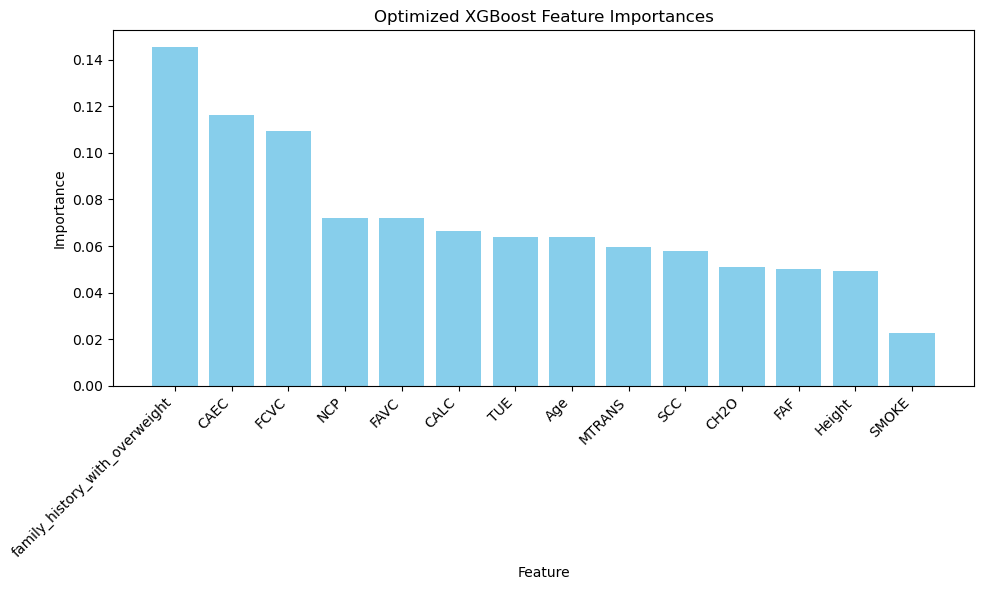

In [245]:
import matplotlib.pyplot as plt

# Create the bar plot
plt.figure(figsize=(10, 6))
plt.bar(feature_importance_df['feature'], feature_importance_df['importance'], color='skyblue')
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.title('Optimized XGBoost Feature Importances')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("xgb_final_feature_importances.png", dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
Obesity class: Insufficient Weight, Normal Weight, Overweight Level I, \nOverweight Level II, Obesity Type I, Obesity Type II, Obesity Type III

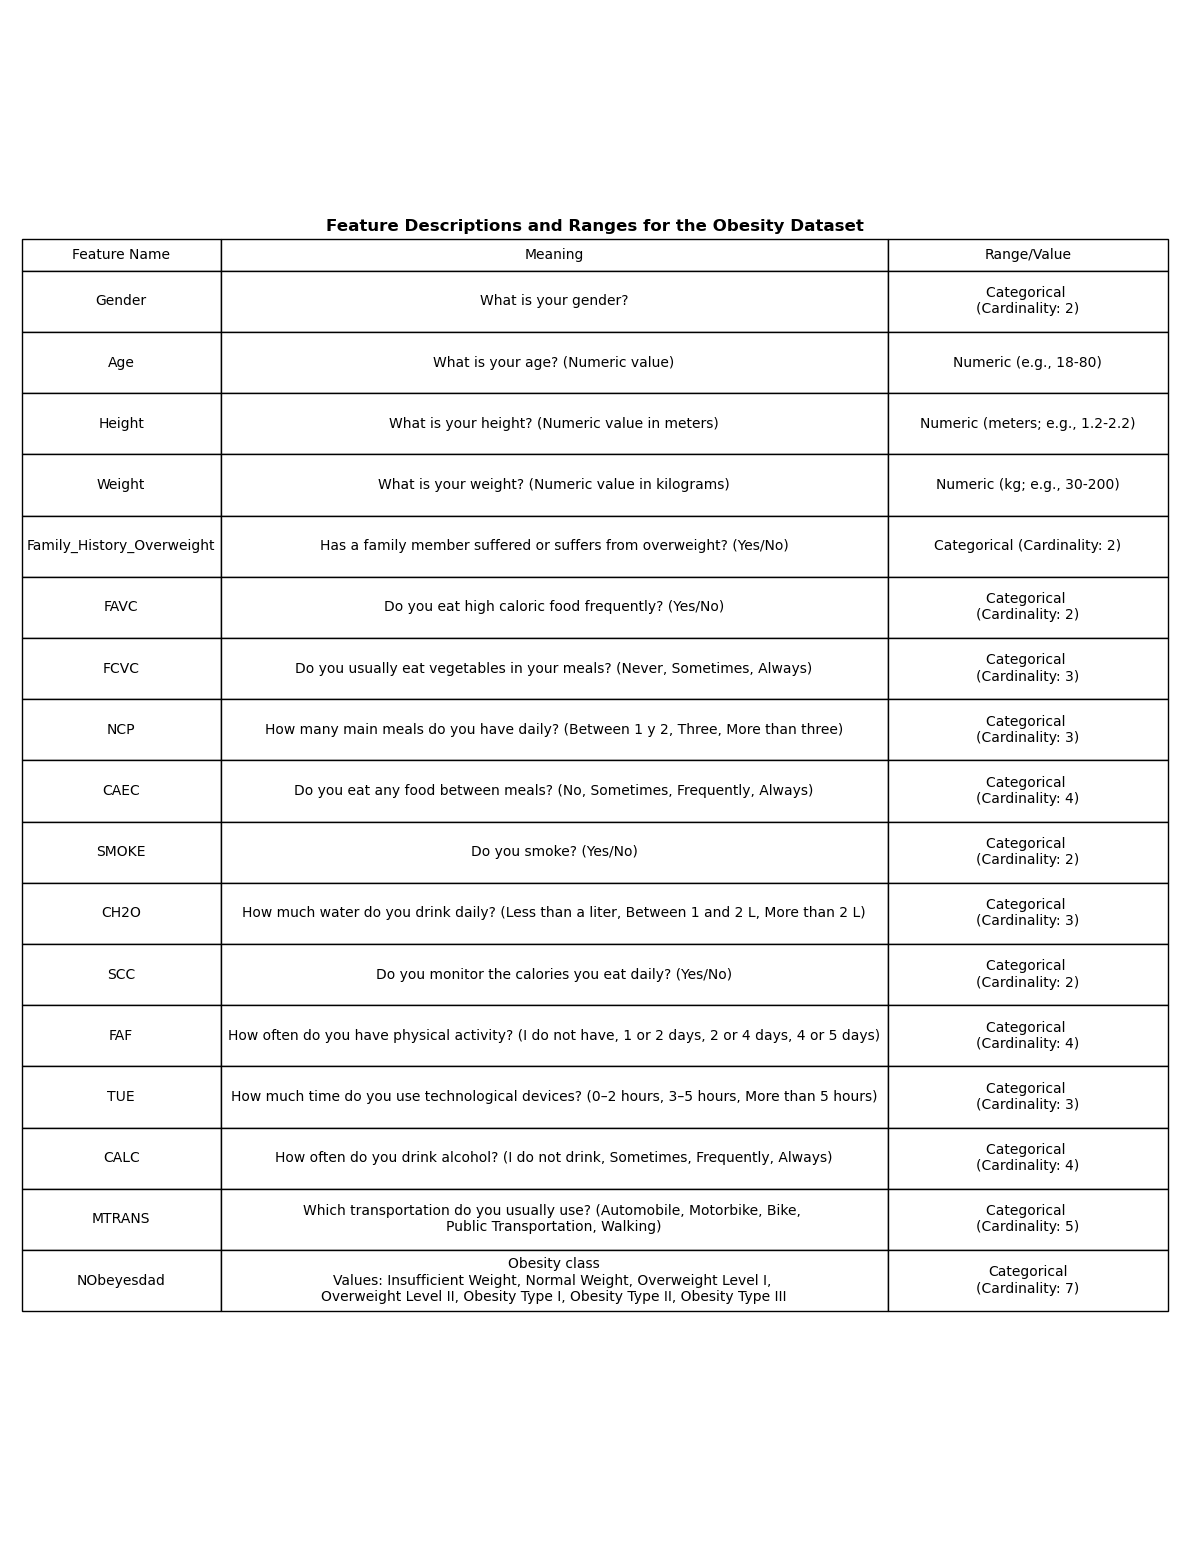

In [481]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Define the list of features corresponding to the survey questions.
features = [
    "Gender", 
    "Age", 
    "Height", 
    "Weight", 
    "Family_History_Overweight", 
    "FAVC", 
    "FCVC", 
    "NCP", 
    "CAEC", 
    "SMOKE", 
    "CH2O", 
    "SCC", 
    "FAF", 
    "TUE", 
    "CALC", 
    "MTRANS",
    "NObeyesdad"
]

# Define the corresponding question (meaning) for each feature.
meanings = {
    "Gender": "What is your gender?",
    "Age": "What is your age? (Numeric value)",
    "Height": "What is your height? (Numeric value in meters)",
    "Weight": "What is your weight? (Numeric value in kilograms)",
    "Family_History_Overweight": "Has a family member suffered or suffers from overweight? (Yes/No)",
    "FAVC": "Do you eat high caloric food frequently? (Yes/No)",
    "FCVC": "Do you usually eat vegetables in your meals? (Never, Sometimes, Always)",
    "NCP": "How many main meals do you have daily? (Between 1 y 2, Three, More than three)",
    "CAEC": "Do you eat any food between meals? (No, Sometimes, Frequently, Always)",
    "SMOKE": "Do you smoke? (Yes/No)",
    "CH2O": "How much water do you drink daily? (Less than a liter, Between 1 and 2 L, More than 2 L)",
    "SCC": "Do you monitor the calories you eat daily? (Yes/No)",
    "FAF": "How often do you have physical activity? (I do not have, 1 or 2 days, 2 or 4 days, 4 or 5 days)",
    "TUE": "How much time do you use technological devices? (0–2 hours, 3–5 hours, More than 5 hours)",
    "CALC": "How often do you drink alcohol? (I do not drink, Sometimes, Frequently, Always)",
    "MTRANS": "Which transportation do you usually use? (Automobile, Motorbike, Bike, \nPublic Transportation, Walking)",
    "NObeyesdad": "Obesity class\nValues: Insufficient Weight, Normal Weight, Overweight Level I, \nOverweight Level II, Obesity Type I, Obesity Type II, Obesity Type III"
}


# Define the range/values (or cardinalities) for each feature.
ranges = {
    "Gender": "Categorical \n(Cardinality: 2)",
    "Age": "Numeric (e.g., 18-80)",
    "Height": "Numeric (meters; e.g., 1.2-2.2)",
    "Weight": "Numeric (kg; e.g., 30-200)",
    "Family_History_Overweight": "Categorical (Cardinality: 2)",
    "FAVC": "Categorical \n(Cardinality: 2)",
    "FCVC": "Categorical \n(Cardinality: 3)",
    "NCP": "Categorical \n(Cardinality: 3)",
    "CAEC": "Categorical \n(Cardinality: 4)",
    "SMOKE": "Categorical \n(Cardinality: 2)",
    "CH2O": "Categorical \n(Cardinality: 3)",
    "SCC": "Categorical \n(Cardinality: 2)",
    "FAF": "Categorical \n(Cardinality: 4)",
    "TUE": "Categorical \n(Cardinality: 3)",
    "CALC": "Categorical \n(Cardinality: 4)",
    "MTRANS": "Categorical \n(Cardinality: 5)",
    "NObeyesdad": "Categorical\n(Cardinality: 7)"
}

# Build the summary data dictionary.
summary_data = {
    "Feature Name": features,
    "Meaning": [meanings.get(feat, "") for feat in features],
    "Range/Value": [ranges.get(feat, "") for feat in features]
}

# Create a DataFrame from the summary data.
df_summary = pd.DataFrame(summary_data)

# Create a figure and axis for the table.
fig, ax = plt.subplots(figsize=(12, len(df_summary)*0.8 + 2))
ax.axis('tight')
ax.axis('off')

# Create the table.
table = ax.table(cellText=df_summary.values,
                 colLabels=df_summary.columns,
                 cellLoc='center',
                 loc='center')

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.5)

# Adjust column widths: make the middle column ("Meaning") wider, others thinner.
n_rows = len(df_summary) + 1  # +1 for header row
for i in range(n_rows):
    table[(i, 0)].set_width(0.17)   # Feature Name column (narrow)
    table[(i, 1)].set_width(0.57)  # Meaning column (wider)
    table[(i, 2)].set_width(0.24)  # Range/Value column (narrow)

# Optionally adjust row height if needed.
for i in range(1, n_rows):
    # For this example, we use a constant height; you can customize per feature if needed.
    table[(i, 0)].set_height(0.04)
    table[(i, 1)].set_height(0.04)
    table[(i, 2)].set_height(0.04)

# Set the title of the table. Adjust 'y' to position it closer.
plt.title("Feature Descriptions and Ranges for the Obesity Dataset", fontweight="bold", y=0.85)

# Adjust layout and save the figure.
plt.tight_layout()
plt.savefig("obesity_feature_summary.png", dpi=300, bbox_inches='tight', pad_inches=0)
plt.show()


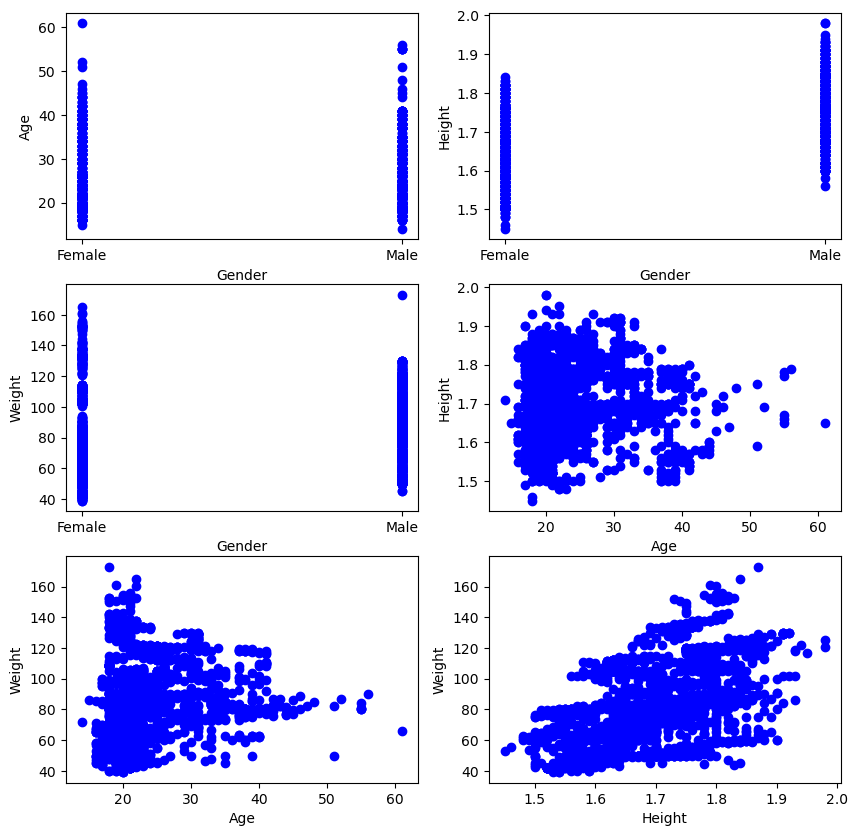

In [375]:
import numpy as np
data = df.copy()
fig, axes = plt.subplots(3, 2, figsize=(10, 10))
x = 0
for i in range(3):
    for j in range(i + 1, 4):
        ax1 = int(x / 2)
        ax2 = x % 2
        axes[ax1][ax2].scatter(data[data.columns[i]], data[data.columns[j]], color='blue')
        axes[ax1][ax2].set_xlabel(data.columns[i])
        axes[ax1][ax2].set_ylabel(data.columns[j])
        x = x + 1

Number of obese individuals: 203
Average obesity probability (before): 0.902
Average obesity probability (after):  0.540


/var/folders/qj/7dpm5g592c99n49ygpwx4m9c0000gn/T/ipykernel_74755/182580213.py:131: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(orig_obesity, label='Obesity Prob. (Original)', shade=True)
/var/folders/qj/7dpm5g592c99n49ygpwx4m9c0000gn/T/ipykernel_74755/182580213.py:132: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(adj_obesity, label='Obesity Prob. (Adjusted)', shade=True)


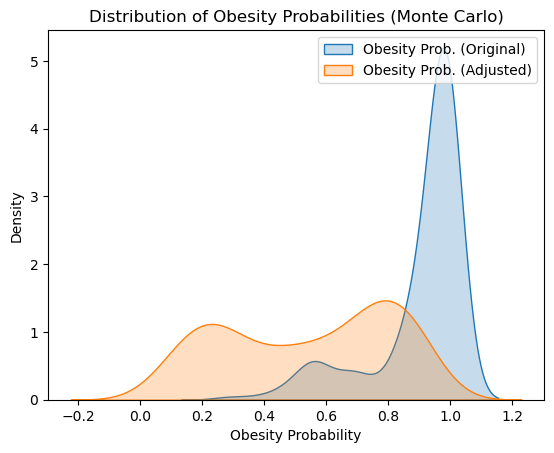

Patient index: 3
  Original modifiable features (FAF, SCC, CAEC, CH2O): [0.48 0.   2.   2.64]
  Original probabilities: [1.1949050e-03 7.4778736e-04 1.1819354e-02 1.3149910e-03 9.7847694e-01
 5.7260068e-03 7.1996701e-04]
  Optimal changes (delta): [ 0.15        1.         -0.15        0.36144731]
  Adjusted probabilities: [0.06775452 0.12804228 0.07600921 0.00733832 0.646633   0.06244178
 0.01178089]

Patient index: 4
  Original modifiable features (FAF, SCC, CAEC, CH2O): [1.99 0.   2.   1.  ]
  Original probabilities: [4.1097222e-04 6.6004822e-04 2.4643911e-03 9.8641521e-01 1.6962744e-04
 1.0607692e-03 8.8189496e-03]
  Optimal changes (delta): [ 0.25165689  1.         -0.28061163  0.71963919]
  Adjusted probabilities: [0.15508847 0.0579608  0.03238021 0.16867831 0.00203817 0.02330055
 0.5605535 ]

Patient index: 5
  Original modifiable features (FAF, SCC, CAEC, CH2O): [0.88 0.   2.   2.  ]
  Original probabilities: [3.0382285e-03 1.3203683e-02 9.6702987e-01 1.6160196e-03 3.6908194e-04

In [668]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assume final_model is defined and X_test is a pandas DataFrame.
# Also assume final_model has a predict_proba method and a predict method.

# --- Configuration ---

# Class order:
# 0: Insufficient_Weight, 1: Normal_Weight, 2: Obesity_Type_I,
# 3: Obesity_Type_II, 4: Obesity_Type_III, 5: Overweight_Level_I, 6: Overweight_Level_II
obese_class_indices = {2, 3, 4}  # target group

# Define the modifiable features:
mod_features = ["FAF", "SCC", "CAEC", "CH2O"]

# Hyperparameters for the objective function:
epsilon = 1e-8   # To avoid log(0)
T = 0.1          # Threshold for Insufficient_Weight probability
alpha = 100      # Penalty factor if p(insufficient) exceeds T
lambd = 0.1      # Regularization for delta magnitude

# Monte Carlo configuration:
n_MC = 500   # number of Monte Carlo samples per obese individual

# --- Objective Function ---

def objective_delta(delta, X_i, mod_features, final_model):
    """
    Given a candidate delta (change for modifiable features) for a patient X_i,
    compute the loss defined as:
    
      loss = log( p_obesity(delta) + epsilon )
             + alpha * max(0, p_insufficient(delta) - T)^2
             + lambd * ||delta||^2
             
    where:
      - p_obesity(delta) = sum of probabilities for Obesity_Type_I, II, III.
      - p_insufficient(delta) = probability for Insufficient_Weight.
    """
    X_new = X_i.copy()
    for idx, col in enumerate(mod_features):
        X_new[col] = X_new[col] + delta[idx]
    X_new_arr = X_new.values.reshape(1, -1)
    probs = final_model.predict_proba(X_new_arr)[0]
    # Sum of obesity probabilities (classes 2, 3, 4)
    p_obesity = probs[2] + probs[3] + probs[4]
    p_insufficient = probs[0]
    loss = np.log(p_obesity + epsilon) + alpha * max(0, p_insufficient - T)**2 + lambd * np.sum(delta**2)
    return loss

# --- Monte Carlo Simulation for Obese Individuals ---

# Identify obese individuals based on final_model predictions.
predicted_labels = final_model.predict(X_test)
obese_indices = [i for i in range(X_test.shape[0]) if predicted_labels[i] in obese_class_indices]

# Lists to store results:
optimal_deltas_MC = []
original_probs = []
adjusted_probs = []

# Loop over each obese individual.
for i in obese_indices:
    X_i = X_test.iloc[i]
    # Get original prediction probabilities
    orig_prob = final_model.predict_proba(X_i.values.reshape(1, -1))[0]
    original_probs.append(orig_prob)
    
    # Get the original modifiable feature values (as floats)
    original_mod = X_i[mod_features].values.astype(np.float64)
    
    best_loss = np.inf
    best_delta = None
    # Monte Carlo sampling: generate candidate deltas.
    for _ in range(n_MC):
        # Sample candidate delta for FAF, CAEC, and CH2O from a normal distribution.
        # For SCC, we will set it categorically.
        candidate_delta = np.random.normal(loc=0, scale=0.2, size=len(mod_features))
        
        # Impose directional constraints:
        # For FAF (index 0): only allow an increase; clip between 0.19 and 1.
        candidate_delta[0] = np.abs(candidate_delta[0])
        candidate_delta[0] = np.clip(candidate_delta[0], 0.15, 2)
        
        # For SCC (index 1): categorical; force it to 1.
        candidate_delta[1] = 1
        
        # For CAEC (index 2): only allow a decrease; clip between -1 and -0.22.
        candidate_delta[2] = -np.abs(candidate_delta[2])
        candidate_delta[2] = np.clip(candidate_delta[2], -1, -0.15)
        
        # For CH2O (index 3): only allow an increase; clip between 0.1 and 1.
        candidate_delta[3] = np.abs(candidate_delta[3])
        candidate_delta[3] = np.clip(candidate_delta[3], 0.15, 1)
        
        loss = objective_delta(candidate_delta, X_i, mod_features, final_model)
        if loss < best_loss:
            best_loss = loss
            best_delta = candidate_delta
            
    optimal_deltas_MC.append(best_delta)
    
    # Apply the best delta to compute adjusted probabilities.
    X_new = X_i.copy()
    for idx, col in enumerate(mod_features):
        X_new[col] = X_new[col] + best_delta[idx]
    new_prob = final_model.predict_proba(X_new.values.reshape(1, -1))[0]
    adjusted_probs.append(new_prob)

optimal_deltas_MC = np.array(optimal_deltas_MC)
original_probs = np.array(original_probs)
adjusted_probs = np.array(adjusted_probs)

# --- Analysis ---

def sum_obesity(probs):
    return probs[2] + probs[3] + probs[4]

orig_obesity = [sum_obesity(p) for p in original_probs]
adj_obesity = [sum_obesity(p) for p in adjusted_probs]

print("Number of obese individuals:", len(obese_indices))
print("Average obesity probability (before): {:.3f}".format(np.mean(orig_obesity)))
print("Average obesity probability (after):  {:.3f}".format(np.mean(adj_obesity)))

# --- Visualization ---

sns.kdeplot(orig_obesity, label='Obesity Prob. (Original)', shade=True)
sns.kdeplot(adj_obesity, label='Obesity Prob. (Adjusted)', shade=True)
plt.xlabel("Obesity Probability")
plt.ylabel("Density")
plt.title("Distribution of Obesity Probabilities (Monte Carlo)")
plt.legend()
plt.savefig("obese_probabilities_distribution_MC.png", dpi=300)
plt.show()

# --- Example Outputs ---

for j in range(min(5, len(obese_indices))):
    idx = obese_indices[j]
    print(f"Patient index: {idx}")
    print("  Original modifiable features (FAF, SCC, CAEC, CH2O):", X_test.iloc[idx][mod_features].values)
    print("  Original probabilities:", original_probs[j])
    print("  Optimal changes (delta):", optimal_deltas_MC[j])
    print("  Adjusted probabilities:", adjusted_probs[j])
    print("")

# --- Summarize Recommended Changes as a Range (10th-90th Percentiles) ---

if optimal_deltas_MC.shape[0] > 0:
    print("Summary of Recommended Changes (Delta) for Obese Individuals (10th-90th Percentiles):")
    for idx, feature in enumerate(mod_features):
        feature_deltas = optimal_deltas_MC[:, idx]
        p10 = np.percentile(feature_deltas, 10)
        p90 = np.percentile(feature_deltas, 90)
        # For SCC, round to the nearest integer.
        if feature == "SCC":
            p10 = float(round(p10))
            p90 = float(round(p90))
        print(f"  {feature}: {p10:.2f} to {p90:.2f}")
else:
    print("No optimal recommendations computed.")


In [681]:
adj_obesity = [i[2] + i[3] + i[4] for i in adjusted_probs]
orig_obesity = [i[2] + i[3] + i[4] for i in original_probs]
# Compute mean reduction in obesity probability
mean_reduction = np.mean([a_i - b_i for a_i, b_i in zip(orig_obesity, adj_obesity)])

# Compute standard deviation of the reduction
std_reduction = np.std([a_i - b_i for a_i, b_i in zip(orig_obesity, adj_obesity)], ddof=1)

# Compute standard error
n = len(orig_obesity)  # Number of obese individuals
se_reduction = std_reduction / np.sqrt(n)

# Z-score for 95% confidence interval
z = 1.96

# Compute confidence interval
ci_reduction = (
    mean_reduction - z * se_reduction, 
    mean_reduction + z * se_reduction
)

# Print results
print(f"Mean Reduction in Obesity Probability: {mean_reduction:.4f}")
print(f"95% Confidence Interval: ({ci_reduction[0]:.4f}, {ci_reduction[1]:.4f})")

Mean Reduction in Obesity Probability: 0.3614
95% Confidence Interval: (0.3314, 0.3914)


In [684]:
n

203

/var/folders/qj/7dpm5g592c99n49ygpwx4m9c0000gn/T/ipykernel_74755/1809557848.py:11: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(orig_obesity, label='Obesity Prob. (Original)', shade=True, ax=ax, color='#f1e36b')
/var/folders/qj/7dpm5g592c99n49ygpwx4m9c0000gn/T/ipykernel_74755/1809557848.py:12: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(adj_obesity, label='Obesity Prob. (Adjusted)', shade=True, ax=ax, color='lightblue')


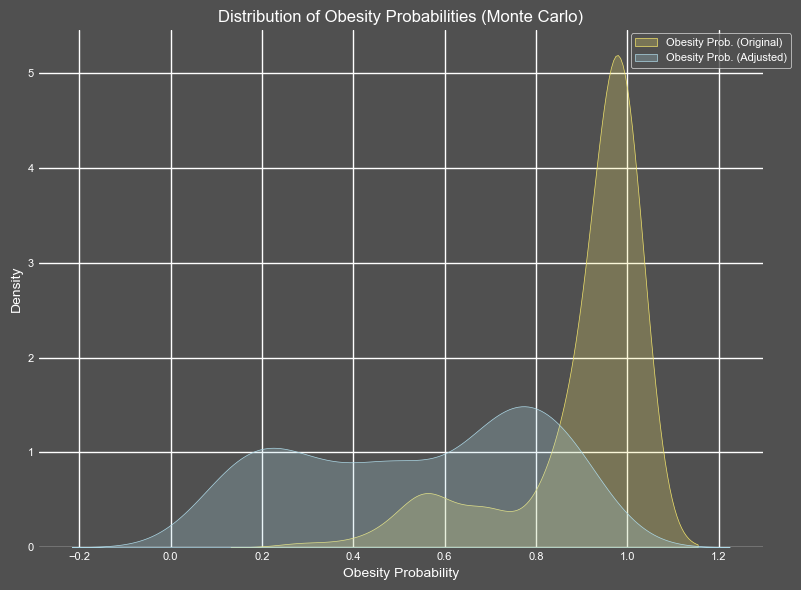

In [639]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-darkgrid')

fig, ax = plt.subplots(figsize=(8, 6))
dark_gray = '#505050'
fig.patch.set_facecolor(dark_gray)
ax.set_facecolor(dark_gray)

sns.kdeplot(orig_obesity, label='Obesity Prob. (Original)', shade=True, ax=ax, color='#f1e36b')
sns.kdeplot(adj_obesity, label='Obesity Prob. (Adjusted)', shade=True, ax=ax, color='lightblue')

# Set smaller font sizes for labels and title
ax.set_xlabel("Obesity Probability", fontsize=10, color="white")
ax.set_ylabel("Density", fontsize=10, color="white")
ax.set_title("Distribution of Obesity Probabilities (Monte Carlo)", fontsize=12, color="white")

# Set tick parameters with a smaller font size
ax.tick_params(colors="white", labelsize=8)

# Shift legend to the right, reduce its font size, and put it in a box.
legend = ax.legend(loc='upper left', bbox_to_anchor=(0.81, 1.005), fontsize=8, frameon=True)
legend.get_frame().set_edgecolor("white")
legend.get_frame().set_facecolor(dark_gray)
for text in legend.get_texts():
    text.set_color("white")

plt.tight_layout()
plt.savefig("obese_probabilities_distribution_MC_gray.png", dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()


/var/folders/qj/7dpm5g592c99n49ygpwx4m9c0000gn/T/ipykernel_74755/2714110213.py:13: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(orig_obesity, label='Obesity Prob. (Original)', shade=True, ax=ax, color='lightblue')
/var/folders/qj/7dpm5g592c99n49ygpwx4m9c0000gn/T/ipykernel_74755/2714110213.py:14: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(adj_obesity, label='Obesity Prob. (Adjusted)', shade=True, ax=ax, color='orange')


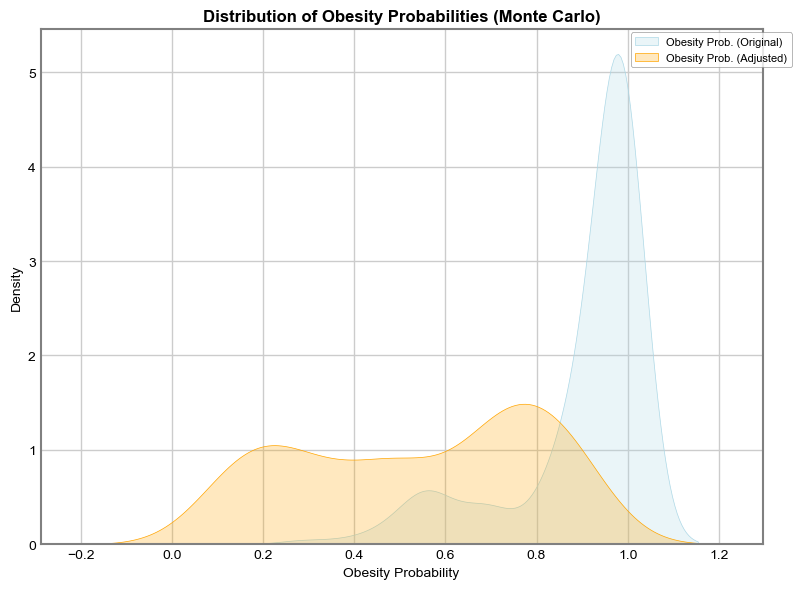

In [625]:
import matplotlib.pyplot as plt
import seaborn as sns

# Explicitly update rcParams to use Times New Roman


plt.style.use('seaborn-v0_8-whitegrid')

fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

sns.kdeplot(orig_obesity, label='Obesity Prob. (Original)', shade=True, ax=ax, color='lightblue')
sns.kdeplot(adj_obesity, label='Obesity Prob. (Adjusted)', shade=True, ax=ax, color='orange')

# Set axis labels and title
ax.set_xlabel("Obesity Probability", fontsize=10, color="black")
ax.set_ylabel("Density", fontsize=10, color="black")
ax.set_title("Distribution of Obesity Probabilities (Monte Carlo)", fontsize=12, color="black", fontweight = "bold")

# Set tick parameters with a smaller font size
ax.tick_params(colors="black", labelsize=10)

# Place the legend in a box and shift it to the right.
legend = ax.legend(loc='upper left', bbox_to_anchor=(0.81, 1.005), fontsize=8, frameon=True)
legend.get_frame().set_edgecolor("gray")
legend.get_frame().set_facecolor("white")
for text in legend.get_texts():
    text.set_color("black")

# Add a gray border around the plot by setting the spines.
for spine in ax.spines.values():
    spine.set_edgecolor('gray')
    spine.set_linewidth(1.5)

plt.tight_layout()
plt.savefig("obese_probabilities_distribution_MC_white.png", dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()


Number of overweight individuals: 104
Average overweight probability (before): 0.833
Average overweight probability (after):  0.698
Average obesity probability (before): 0.105
Average obesity probability (after):  0.079


/var/folders/qj/7dpm5g592c99n49ygpwx4m9c0000gn/T/ipykernel_74755/1099415576.py:144: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(orig_overweight, label='Overweight Prob. (Original)', shade=True)
/var/folders/qj/7dpm5g592c99n49ygpwx4m9c0000gn/T/ipykernel_74755/1099415576.py:145: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(adj_overweight, label='Overweight Prob. (Adjusted)', shade=True)


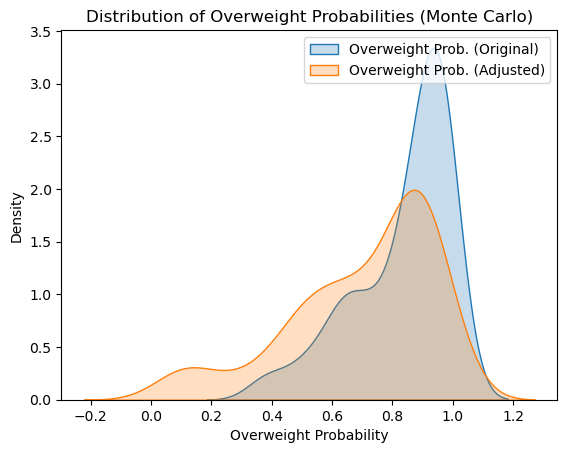

Patient index: 2
  Original modifiable features (FAF, SCC, CAEC, CH2O): [0.   0.   2.   2.88]
  Original probabilities: [0.00546185 0.00638071 0.10441042 0.00619465 0.01525227 0.06242112
 0.79987895]
  Optimal changes (delta): [ 0.15  1.   -0.15  0.15]
  Adjusted probabilities: [0.06485273 0.05021695 0.04839515 0.00681996 0.01287726 0.19270207
 0.6241359 ]

Patient index: 9
  Original modifiable features (FAF, SCC, CAEC, CH2O): [0.11 1.   2.   2.  ]
  Original probabilities: [1.51089177e-01 1.25053665e-02 3.81587120e-03 1.86866464e-03
 4.66600497e-04 8.26805830e-01 3.44848214e-03]
  Optimal changes (delta): [ 0.20942604  1.         -0.15        0.18001739]
  Adjusted probabilities: [0.29535505 0.01892996 0.00555462 0.00204121 0.00111974 0.67281866
 0.00418077]

Patient index: 13
  Original modifiable features (FAF, SCC, CAEC, CH2O): [1.   0.   3.   2.81]
  Original probabilities: [8.4518060e-02 4.9198028e-03 7.9833278e-03 1.0803636e-03 8.0571638e-04
 8.9655882e-01 4.1338806e-03]
  Opti

In [685]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assume final_model is defined and X_test is a pandas DataFrame.
# Also assume final_model has a predict_proba method and a predict method.

# --- Configuration ---

# Class order:
# 0: Insufficient_Weight, 1: Normal_Weight, 2: Obesity_Type_I,
# 3: Obesity_Type_II, 4: Obesity_Type_III, 5: Overweight_Level_I, 6: Overweight_Level_II

overweight_class_indices = {5, 6}  # target group

# Define the modifiable features:
mod_features = ["FAF", "SCC", "CAEC", "CH2O"]

# Hyperparameters for the objective function:
epsilon = 1e-8   # To avoid log(0)
T = 0.1          # Threshold for Obesity probability constraint
alpha = 100      # Penalty factor if p(obesity) exceeds T
beta = 100       # Penalty factor if p(insufficient) increases
lambd = 0.1      # Regularization for delta magnitude

# Monte Carlo configuration:
n_MC = 500   # number of Monte Carlo samples per overweight individual

# --- Objective Function ---

def objective_delta(delta, X_i, mod_features, final_model):
    """
    Given a candidate delta (change for modifiable features) for a patient X_i,
    compute the loss defined as:
    
      loss = log( p_overweight(delta) + epsilon )
             + alpha * max(0, p_obesity(delta) - p_obesity_orig)**2
             + beta * max(0, p_insufficient(delta) - p_insufficient_orig)**2
             + lambd * ||delta||^2
             
    where:
      - p_overweight(delta) = sum of probabilities for Overweight_Level_I and II.
      - p_obesity(delta) = sum of probabilities for Obesity_Type_I, II, III.
      - p_obesity_orig is the original obesity probability before applying delta.
      - p_insufficient(delta) = probability for Insufficient_Weight.
      - p_insufficient_orig is the original insufficient weight probability before applying delta.
    """
    X_new = X_i.copy()
    for idx, col in enumerate(mod_features):
        X_new[col] = X_new[col] + delta[idx]
    X_new_arr = X_new.values.reshape(1, -1)
    probs = final_model.predict_proba(X_new_arr)[0]
    
    p_overweight = probs[5] + probs[6]
    p_obesity = probs[2] + probs[3] + probs[4]
    p_insufficient = probs[0]
    
    orig_probs = final_model.predict_proba(X_i.values.reshape(1, -1))[0]
    p_obesity_orig = orig_probs[2:5].sum()
    p_insufficient_orig = orig_probs[0]
    
    loss = (np.log(p_overweight + epsilon) 
            + alpha * max(0, p_obesity - p_obesity_orig)**2
            + beta * max(0, p_insufficient - p_insufficient_orig)**2
            + lambd * np.sum(delta**2))
    return loss

# --- Monte Carlo Simulation for Overweight Individuals ---

# Identify overweight individuals based on final_model predictions.
predicted_labels = final_model.predict(X_test)
overweight_indices = [i for i in range(X_test.shape[0]) if predicted_labels[i] in overweight_class_indices]

# Lists to store results:
optimal_deltas_MC = []
original_probs = []
adjusted_probs = []

# Loop over each overweight individual.
for i in overweight_indices:
    X_i = X_test.iloc[i]
    # Get original prediction probabilities
    orig_prob = final_model.predict_proba(X_i.values.reshape(1, -1))[0]
    original_probs.append(orig_prob)
    
    best_loss = np.inf
    best_delta = None
    # Monte Carlo sampling: generate candidate deltas.
    for _ in range(n_MC):
        candidate_delta = np.random.normal(loc=0, scale=0.2, size=len(mod_features))
        
        # Impose directional constraints:
        candidate_delta[0] = np.abs(candidate_delta[0])  # FAF (increase)
        candidate_delta[0] = np.clip(candidate_delta[0], 0.15, 1)
        
        candidate_delta[1] = 1  # SCC (set to 1)
        
        candidate_delta[2] = -np.abs(candidate_delta[2])  # CAEC (decrease)
        candidate_delta[2] = np.clip(candidate_delta[2], -1, -0.15)
        
        candidate_delta[3] = np.abs(candidate_delta[3])  # CH2O (increase)
        candidate_delta[3] = np.clip(candidate_delta[3], 0.15, 1)
        
        loss = objective_delta(candidate_delta, X_i, mod_features, final_model)
        if loss < best_loss:
            best_loss = loss
            best_delta = candidate_delta
            
    optimal_deltas_MC.append(best_delta)
    
    # Apply the best delta to compute adjusted probabilities.
    X_new = X_i.copy()
    for idx, col in enumerate(mod_features):
        X_new[col] = X_new[col] + best_delta[idx]
    new_prob = final_model.predict_proba(X_new.values.reshape(1, -1))[0]
    adjusted_probs.append(new_prob)

optimal_deltas_MC = np.array(optimal_deltas_MC)
original_probs = np.array(original_probs)
adjusted_probs = np.array(adjusted_probs)

# --- Analysis ---

def sum_overweight(probs):
    return probs[5] + probs[6]

def sum_obesity(probs):
    return probs[2] + probs[3] + probs[4]

orig_overweight = [sum_overweight(p) for p in original_probs]
adj_overweight = [sum_overweight(p) for p in adjusted_probs]
orig_obesity = [sum_obesity(p) for p in original_probs]
adj_obesity = [sum_obesity(p) for p in adjusted_probs]

print("Number of overweight individuals:", len(overweight_indices))
print("Average overweight probability (before): {:.3f}".format(np.mean(orig_overweight)))
print("Average overweight probability (after):  {:.3f}".format(np.mean(adj_overweight)))
print("Average obesity probability (before): {:.3f}".format(np.mean(orig_obesity)))
print("Average obesity probability (after):  {:.3f}".format(np.mean(adj_obesity)))

# --- Visualization ---
plt.rcdefaults()
sns.kdeplot(orig_overweight, label='Overweight Prob. (Original)', shade=True)
sns.kdeplot(adj_overweight, label='Overweight Prob. (Adjusted)', shade=True)
plt.xlabel("Overweight Probability")
plt.ylabel("Density")
plt.title("Distribution of Overweight Probabilities (Monte Carlo)")
plt.legend()
#plt.savefig("overweight_probabilities_distribution_MC.png", dpi=300)
plt.show()

# --- Example Outputs ---

for j in range(min(5, len(overweight_indices))):
    idx = overweight_indices[j]
    print(f"Patient index: {idx}")
    print("  Original modifiable features (FAF, SCC, CAEC, CH2O):", X_test.iloc[idx][mod_features].values)
    print("  Original probabilities:", original_probs[j])
    print("  Optimal changes (delta):", optimal_deltas_MC[j])
    print("  Adjusted probabilities:", adjusted_probs[j])
    print("")

print("95% Range of Recommended Changes for Overweight Individuals:")
for idx, feature in enumerate(mod_features):
    feature_data = optimal_deltas_MC[:, idx]
    lower_bound = np.percentile(feature_data, 2.5)
    upper_bound = np.percentile(feature_data, 97.5)
    # For categorical features (e.g., SCC), round the bounds.
    if feature in ["SCC"]:
        lower_bound = round(lower_bound)
        upper_bound = round(upper_bound)
    print(f"  {feature}: {lower_bound:.2f} to {upper_bound:.2f}")


In [688]:
adj_obesity = [i[5] + i[6] for i in adjusted_probs]
orig_obesity = [i[5] + i[6] for i in original_probs]
# Compute mean reduction in obesity probability
mean_reduction = np.mean([a_i - b_i for a_i, b_i in zip(orig_obesity, adj_obesity)])

# Compute standard deviation of the reduction
std_reduction = np.std([a_i - b_i for a_i, b_i in zip(orig_obesity, adj_obesity)], ddof=1)

# Compute standard error
n = len(orig_obesity)  # Number of obese individuals
se_reduction = std_reduction / np.sqrt(n)

# Z-score for 95% confidence interval
z = 1.96

# Compute confidence interval
ci_reduction = (
    mean_reduction - z * se_reduction, 
    mean_reduction + z * se_reduction
)

# Print results
print(f"Mean Reduction in Obesity Probability: {mean_reduction:.4f}")
print(f"95% Confidence Interval: ({ci_reduction[0]:.4f}, {ci_reduction[1]:.4f})")

Mean Reduction in Obesity Probability: 0.1350
95% Confidence Interval: (0.0980, 0.1719)


In [689]:
adj_obesity = [i[2] + i[3] + i[4] for i in adjusted_probs]
orig_obesity = [i[2] + i[3] + i[4] for i in original_probs]
# Compute mean reduction in obesity probability
mean_reduction = np.mean([a_i - b_i for a_i, b_i in zip(orig_obesity, adj_obesity)])

# Compute standard deviation of the reduction
std_reduction = np.std([a_i - b_i for a_i, b_i in zip(orig_obesity, adj_obesity)], ddof=1)

# Compute standard error
n = len(orig_obesity)  # Number of obese individuals
se_reduction = std_reduction / np.sqrt(n)

# Z-score for 95% confidence interval
z = 1.96

# Compute confidence interval
ci_reduction = (
    mean_reduction - z * se_reduction, 
    mean_reduction + z * se_reduction
)

# Print results
print(f"Mean Reduction in Obesity Probability: {mean_reduction:.4f}")
print(f"95% Confidence Interval: ({ci_reduction[0]:.4f}, {ci_reduction[1]:.4f})")

Mean Reduction in Obesity Probability: 0.0260
95% Confidence Interval: (0.0100, 0.0420)


/var/folders/qj/7dpm5g592c99n49ygpwx4m9c0000gn/T/ipykernel_74755/2503310624.py:13: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(orig_overweight, label='Obesity Prob. (Original)', shade=True, ax=ax, color='lightblue')
/var/folders/qj/7dpm5g592c99n49ygpwx4m9c0000gn/T/ipykernel_74755/2503310624.py:14: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(adj_overweight, label='Obesity Prob. (Adjusted)', shade=True, ax=ax, color='orange')


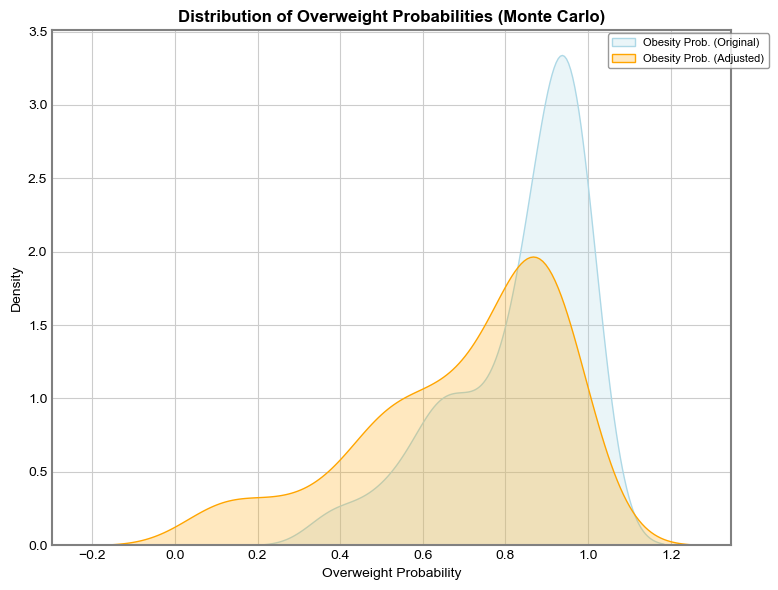

In [650]:
import matplotlib.pyplot as plt
import seaborn as sns

# Explicitly update rcParams to use Times New Roman


plt.style.use('seaborn-v0_8-whitegrid')

fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

sns.kdeplot(orig_overweight, label='Obesity Prob. (Original)', shade=True, ax=ax, color='lightblue')
sns.kdeplot(adj_overweight, label='Obesity Prob. (Adjusted)', shade=True, ax=ax, color='orange')

# Set axis labels and title
ax.set_xlabel("Overweight Probability", fontsize=10, color="black")
ax.set_ylabel("Density", fontsize=10, color="black")
ax.set_title("Distribution of Overweight Probabilities (Monte Carlo)", fontsize=12, color="black", fontweight = "bold")

# Set tick parameters with a smaller font size
ax.tick_params(colors="black", labelsize=10)

# Place the legend in a box and shift it to the right.
legend = ax.legend(loc='upper left', bbox_to_anchor=(0.81, 1.005), fontsize=8, frameon=True)
legend.get_frame().set_edgecolor("gray")
legend.get_frame().set_facecolor("white")
for text in legend.get_texts():
    text.set_color("black")

# Add a gray border around the plot by setting the spines.
for spine in ax.spines.values():
    spine.set_edgecolor('gray')
    spine.set_linewidth(1.5)

plt.tight_layout()
plt.savefig("overweight_probabilities_distribution_MC_white.png", dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()


In [649]:
print("95% Range of Recommended Changes for Overweight Individuals:")
for idx, feature in enumerate(mod_features):
    feature_data = optimal_deltas_MC[:, idx]
    lower_bound = np.percentile(feature_data, 2.5)
    upper_bound = np.percentile(feature_data, 97.5)
    # For categorical features (e.g., SCC), round the bounds.
    if feature in ["SCC"]:
        lower_bound = round(lower_bound)
        upper_bound = round(upper_bound)
    print(f"  {feature}: {lower_bound:.2f} to {upper_bound:.2f}")


95% Range of Recommended Changes for Overweight Individuals:
  FAF: 0.15 to 0.61
  SCC: 1.00 to 1.00
  CAEC: -0.22 to -0.15
  CH2O: 0.15 to 0.64


In [519]:
print("95% Range of Recommended Changes for Obese Individuals:")
for idx, feature in enumerate(mod_features):
    feature_data = optimal_deltas_MC[:, idx]
    lower_bound = np.percentile(feature_data, 2.5)
    upper_bound = np.percentile(feature_data, 97.5)
    # For categorical features (e.g., SCC), round the bounds.
    if feature in ["SCC"]:
        lower_bound = round(lower_bound)
        upper_bound = round(upper_bound)
    print(f"  {feature}: {lower_bound:.2f} to {upper_bound:.2f}")


95% Range of Recommended Changes for Obese Individuals:
  FAF: 0.15 to 0.78
  SCC: 1.00 to 1.00
  CAEC: -0.33 to -0.15
  CH2O: 0.15 to 0.63


In [637]:
print("95% Range of Recommended Changes for Obese Individuals:")
for idx, feature in enumerate(mod_features):
    feature_data = optimal_deltas_MC[:, idx]
    lower_bound = np.min(feature_data)
    upper_bound = np.max(feature_data)
    # For categorical features (e.g., SCC), round the bounds.
    if feature in ["SCC"]:
        lower_bound = round(lower_bound)
        upper_bound = round(upper_bound)
    print(f"  {feature}: {lower_bound:.2f} to {upper_bound:.2f}")


95% Range of Recommended Changes for Obese Individuals:
  FAF: 0.15 to 0.98
  SCC: 1.00 to 1.00
  CAEC: -0.51 to -0.15
  CH2O: 0.15 to 0.83


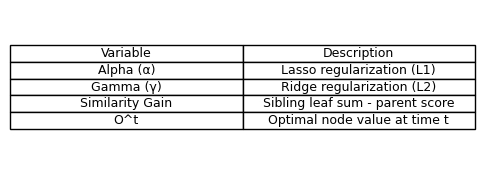

In [659]:
import matplotlib.pyplot as plt
import pandas as pd

# Sample data
data_var = {
    "Variable": ["Alpha (α)", "Gamma (γ)", "Similarity Gain", "O^t"],
    "Description": [
        "Lasso regularization (L1)",
        "Ridge regularization (L2)",
        "Sibling leaf sum - parent score",
        "Optimal node value at time t"
    ]
}

# Convert data into a DataFrame
df_data = pd.DataFrame(data_var)

# Create a figure and axis
fig, ax = plt.subplots(figsize=(6, 2))
ax.axis('tight')
ax.axis('off')

# Create the table
table = ax.table(cellText=df_data.values, colLabels=df_data.columns, cellLoc='center', loc='center')

# Adjust font size
table.auto_set_font_size(False)
table.set_fontsize(9)
plt.title("")

# Display the table
plt.show()


In [663]:
import pickle
file_name = "final_model_xgb.pkl"

# save
pickle.dump(final_model, open(file_name, "wb"))

In [665]:
X_test.to_csv("xgb_test_x.csv")
np.savetxt("xgb_test_y.csv", y_test, delimiter=",")

In [666]:
len(y_test)

423